# NB66REP: Merger rates from population `.h5` files

Replacement for `66_MergerRatesModule.ipynb`. Loads a population DataFrame from HDF5,
computes the per-system intrinsic merger-rate densities **once**, and provides five
plotting functions:

1. `plot_rate_vs_parameter` — metallicity-integrated $\mathrm{d}\mathcal{R}/\mathrm{d}x$ at a fixed redshift, for any float parameter.
2. `plot_mass_rate_pi_comparison` — the same at fixed redshift for `m_post_pi` and `m_f`.
3. `plot_rate_by_metallicity` — $\mathrm{d}\mathcal{R}/\mathrm{d}x$ split by metallicity bin at a fixed redshift.
4. `plot_rate_multi_redshift` — metallicity-integrated $\mathrm{d}\mathcal{R}/\mathrm{d}x$ for several redshifts.
5. `plot_rate_2d` — $\mathrm{d}^2\mathcal{R}/\mathrm{d}x\,\mathrm{d}y$ over two parameters as a colour map.
6. `plot_population_mixture` — smoothed CHE rate mixed with the LVK ~10 M$_\odot$ peak component.
7. `plot_channel_comparison` — CHE and SMT rate curves drawn separately, unmixed.

`MergerRateResult.merger_rate` has shape `(n_merger_systems, n_redshifts)` and holds the
intrinsic merger-rate density in $\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$ contributed by each
simulated system at each redshift. A column slice at fixed $z$ is therefore a per-system
weight vector that is **already integrated over metallicity**; every plot below is a
weighted histogram of that vector.

In [1]:
nb_id = '66REP'

from pathlib import Path
import pickle as pkl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize

from scipy.stats import gaussian_kde, norm

import astropy.units as u

import sys

sys.path.append('..')

from cosmic_integration.cosmology import get_cosmology
from src.util import DATA_DIR, savefig_base
from src.merger_rates import (
    RateComputationConfig,
    RedshiftGridConfig,
    MetallicityConfig,
    build_population_arrays,
    compute_merger_rates,
    compute_parameter_rate_density,
)
from src.popsynth import SamplingConfig

plt.style.use('./plotstyle.mplstyle')

In [2]:
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)


def savefig(fig, fname):
    """Save a figure as png, pdf and eps into this notebook's figure folder."""
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

## Population data and rate ingredients

In [3]:
PARAM_LABELS = {
    'z_div_zsun':      r'$Z/Z_\odot$',
    'm_zams':          r'$M_\mathrm{ZAMS}\,/\,\mathrm{M}_\odot$',
    'p_spin_zams':     r'$P_\mathrm{spin,ZAMS}\,/\,\mathrm{d}$',
    'm_f':             r'$M_f\,/\,\mathrm{M}_\odot$',
    'm_post_pi':       r'$M_\mathrm{post\,PI}\,/\,\mathrm{M}_\odot$',
    'm_tams':          r'$M_\mathrm{TAMS}\,/\,\mathrm{M}_\odot$',
    'm_cocore_tahems': r'$M_\mathrm{CO,TAHeMS}\,/\,\mathrm{M}_\odot$',
    'm_cocore_f':      r'$M_{\mathrm{CO},f}\,/\,\mathrm{M}_\odot$',
    'p_orb_f':         r'$P_{\mathrm{orb},f}\,/\,\mathrm{d}$',
    'x_f':             r'$\chi_f$',
    'x_min_f':         r'$\chi_{\mathrm{min},f}$',
    'x_tams':          r'$\chi_\mathrm{TAMS}$',
    'log_t_d':         r'$\log_{10}(t_d\,/\,\mathrm{yr})$',
}

# parameters binned geometrically by default
LOG_PARAMS = {'p_orb_f', 'x_min_f'}

# parameters whose non-positive entries are unphysical placeholders
PARAM_MIN_POSITIVE = {'m_post_pi'}

RATE_LABEL = r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/\mathrm{d}x$'


def param_label(parameter):
    """Return the LaTeX axis label for a population column."""
    return PARAM_LABELS.get(parameter, parameter.replace('_', r'\_'))


def rate_label(parameter, log_x=False):
    """Return the LaTeX label of the differential rate with respect to a parameter."""
    d = r'\mathrm{d}\log_{10}x' if log_x else r'\mathrm{d}x'
    return (
        r'$\mathrm{d}\mathcal{R}_\mathrm{merger}/' + d
        + r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$'
    )

In [4]:
def load_population(path, key='df'):
    """Load a population sample DataFrame from an HDF5 file.

    Parameters
    ----------
    path : path-like
        Path to an ``ip_pop_*_df.h5`` file.
    key : str
        HDF5 key holding the DataFrame.

    Returns
    -------
    pandas.DataFrame
        The population, with a fresh integer index.
    """
    sample_df = pd.read_hdf(path, key=key)
    return sample_df.reset_index(drop=True)

In [5]:
def compute_population_rates(sample_df, config=None):
    """Compute per-system intrinsic merger-rate densities for a population.

    The rate does not depend on which mass column is used, so a single call
    serves every plot in this notebook.

    Parameters
    ----------
    sample_df : pandas.DataFrame
        Population sample, already filtered with :func:`load_population`.
    config : RateComputationConfig, optional
        Cosmology, SFRD and metallicity-distribution settings.

    Returns
    -------
    merger_df : pandas.DataFrame
        The merging subset of ``sample_df``; row ``i`` corresponds to row ``i``
        of ``rate_result.merger_rate``.
    rate_result : MergerRateResult
        Rate ingredients, with ``merger_rate`` of shape
        ``(len(merger_df), len(rate_result.redshifts))``.
    """
    if config is None:
        config = RateComputationConfig()

    # use one Hubble time for both the array cut and the DataFrame cut
    t_h_yr = get_cosmology().age(0).to(u.yr).value
    full_arr, merger_arr = build_population_arrays(sample_df, t_h_yr=t_h_yr)
    merger_df = sample_df[sample_df.log_t_d < np.log10(t_h_yr)].reset_index(drop=True)

    if len(merger_df) != len(merger_arr):
        raise ValueError('merger_df and merger array are misaligned')

    rate_result = compute_merger_rates(full_arr, merger_arr, config=config)
    return merger_df, rate_result

In [6]:
redshift_config = RedshiftGridConfig(
    max_redshift = 10.,
    redshift_step = 0.01,
    redshift_first_sf = 10.0,
    cosmology = 'WMAP9',
    )

# leave defaults to use van Son et al. (2022) skewed Gaussian
# as implemented in CosmicIntegration
metallicity_config = MetallicityConfig(
    step_logz = 0.01
)

In [7]:
pop_title = 'ip_pop_minz5e-4_maxz1e0_loguniform_interpolator_res1e+09_zextTrue_interpolator_00_fiducial'
POP_PATH = DATA_DIR / f'output/ip_pop/{pop_title}_df.h5'
SAMPLING_CONFIG_PATH = DATA_DIR / f'output/ip_pop/{pop_title}_sampling_config.pkl'
include_brown_dwarfs = False

sampling_config = pkl.load(open(SAMPLING_CONFIG_PATH, 'rb')) 
config = RateComputationConfig(
    sampling=sampling_config, 
    redshift=redshift_config, 
    metallicity=metallicity_config, 
    include_brown_dwarfs=include_brown_dwarfs,
    absolute_logp_min=-1.,
    absolute_logp_max=4.,
)
# config.sampling.q_min = 0.5 # frozen instance
print(f"Assuming minimum mass ratio for CHE is {config.sampling.q_min}")
sample_df = load_population(POP_PATH)
merger_df, rate_result = compute_population_rates(sample_df, config=config)

print(f'population       : {POP_PATH.name}')
print(f'CHE systems      : {len(sample_df)}')
print(f'merging systems  : {len(merger_df)}')
print(f'merger_rate shape: {rate_result.merger_rate.shape}')
print(f'redshift grid    : {rate_result.redshifts[0]} ... {rate_result.redshifts[-1]}')
print(f'sampling configuration: {sampling_config}')
print('float parameters :')
print('   ', [c for c in merger_df.columns if merger_df[c].dtype.kind == 'f'])

Assuming minimum mass ratio for CHE is 0.7
population       : ip_pop_minz5e-4_maxz1e0_loguniform_interpolator_res1e+09_zextTrue_interpolator_00_fiducial_df.h5
CHE systems      : 10000000
merging systems  : 27443
merger_rate shape: (27443, 1001)
redshift grid    : 0.0 ... 10.0
sampling configuration: SamplingConfig(min_z_div_zsun=0.0005, max_z_div_zsun=1.0, m_min=10.0, m_max=300.0, q_min=0.7, q_max=1.0, p_min=0.1, p_max=10000.0)
float parameters :
    ['z_div_zsun', 'm_zams', 'p_spin_zams', 'm_f', 'p_orb_f', 'x_f', 'x_min_f', 'm_tams', 'x_tams', 'log_t_d', 'm_cocore_tahems', 'm_post_pi']


## Core helpers

`rate_weights_at_redshift` is the primitive every plot builds on: it returns the
per-system merger-rate density at a single redshift, summing to $\mathcal{R}(z)$.

In [8]:
class SmoothedRateModel:
    """Weighted Gaussian-KDE model of the differential merger rate at one redshift.

    The bandwidth is a kernel standard deviation in physical units -- solar masses
    for ``space='linear'``, dex for ``space='log'`` -- not a multiple of Scott's
    factor, so it can be compared directly with the width of the features it smooths.

    Parameters
    ----------
    values : array_like
        Parameter values, one per system.
    weights : array_like
        Per-system rate densities at the chosen redshift, in Gpc^-3 yr^-1.
    bandwidth : float
        Kernel standard deviation, in parameter units or dex.
    space : {'linear', 'log'}
        Fit the kernel to the parameter or to its base-10 logarithm.
    parameter : str
        Name of the modelled column, used for labels.
    redshift : float, optionalx
        Redshift the weights were taken at, used for labels.
    clamp_low : float or None
        Mass below which the rate is held flat at its value there rather than
        following the kernel down. ``None`` leaves the kernel untouched.
    clamp_floor : float
        Mass below which the clamped rate is cut to zero.

    Attributes
    ----------
    total_rate : float
        Sum of the weights, i.e. the total rate the density is normalised to.
    support : tuple of float
        Minimum and maximum of the fitted values.
    """

    def __init__(self, values, weights, bandwidth=1.5, space='linear',
                 parameter='m_post_pi', redshift=None,
                 clamp_low=None, clamp_floor=15.0):
        if space not in ('linear', 'log'):
            raise ValueError("space must be 'linear' or 'log'")
        if clamp_low is not None and clamp_floor >= clamp_low:
            raise ValueError('require clamp_floor < clamp_low')

        values = np.asarray(values, dtype=float)
        weights = np.clip(np.asarray(weights, dtype=float), 0.0, None)
        usable = np.isfinite(values) & np.isfinite(weights)
        if space == 'log':
            usable &= values > 0
        values, weights = values[usable], weights[usable]
        if values.size < 2 or weights.sum() <= 0:
            raise ValueError('not enough weighted systems to fit a KDE')

        self.space = space
        self.bandwidth = float(bandwidth)
        self.parameter = parameter
        self.redshift = redshift
        self.total_rate = float(weights.sum())
        self.support = (float(values.min()), float(values.max()))
        self.clamp_low = None if clamp_low is None else float(clamp_low)
        self.clamp_floor = float(clamp_floor)

        # rescale Scott's factor so the kernel standard deviation is `bandwidth`
        sample = np.log10(values) if space == 'log' else values
        self._kde = gaussian_kde(sample, weights=weights)
        sample_std = np.sqrt(self._kde.covariance[0, 0]) / self._kde.factor
        self._kde.set_bandwidth(bw_method=self.bandwidth / sample_std)

    @property
    def label(self):
        """Return a short legend label naming the smoothing used."""
        unit = r'\,\mathrm{dex}' if self.space == 'log' else r'\,\mathrm{M}_\odot'
        return rf'CHE (KDE, $h = {self.bandwidth:g}{unit}$)'

    def _kde_density(self, x):
        """Return the raw kernel density at ``x``, before any clamping."""
        if self.space == 'linear':
            return self._kde.evaluate(x)

        # transform the log-space density back to a density in the parameter
        out = np.zeros_like(x)
        positive = x > 0
        out[positive] = (
            self._kde.evaluate(np.log10(x[positive])) / (x[positive] * np.log(10.0))
        )
        return out

    def density(self, x):
        """Return the probability density of the parameter at ``x``.

        With ``clamp_low`` set, the density below it is held at its clamp value
        and carried down to ``clamp_floor``, below which it is zero. This adds
        area, so a clamped model no longer integrates to one and its rate
        integrates to more than ``total_rate`` -- that extra rate is the point of
        the extension.
        """
        x = np.atleast_1d(np.asarray(x, dtype=float))
        if self.clamp_low is None:
            return self._kde_density(x)

        # hold the kernel at its clamp value, then cut off at the floor
        held = np.where(x < self.clamp_low, self.clamp_low, x)
        return np.where(x < self.clamp_floor, 0.0, self._kde_density(held))

    def rate(self, x):
        """Return dR/dx at ``x`` in Gpc^-3 yr^-1 per unit parameter."""
        return self.total_rate * self.density(x)

In [9]:
def fit_smoothed_rate_model(
    merger_df,
    rate_result,
    parameter='m_post_pi',
    redshift=0.2,
    bandwidth=1.5,
    space='linear',
    clamp_low=None,
    clamp_floor=15.0,
    drop_pisn=True,
):
    """Fit a :class:`SmoothedRateModel` to the population rate at a fixed redshift.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with ``rate_result``.
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    parameter : str
        Column to model.
    redshift : float
        Redshift at which the rate weights are taken.
    bandwidth : float
        Kernel standard deviation, in parameter units or dex.
    space : {'linear', 'log'}
        Space the kernel is fitted in.
    clamp_low, clamp_floor : float
        Low-mass clamp, passed to :class:`SmoothedRateModel`.
    drop_pisn : bool
        Drop PISN systems for columns in ``PARAM_MIN_POSITIVE``.

    Returns
    -------
    SmoothedRateModel
    """
    weights, z_used = rate_weights_at_redshift(rate_result, redshift)
    values, mask = select_parameter(merger_df, parameter, drop_pisn=drop_pisn)
    return SmoothedRateModel(
        values[mask], weights[mask],
        bandwidth=bandwidth, space=space, parameter=parameter, redshift=z_used,
        clamp_low=clamp_low, clamp_floor=clamp_floor,
    )

In [10]:
def rate_weights_at_redshift(rate_result, redshift):
    """Return per-system merger-rate densities at the grid redshift nearest ``redshift``.

    Parameters
    ----------
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    redshift : float
        Requested redshift.

    Returns
    -------
    weights : numpy.ndarray
        Shape ``(n_systems,)``, in Gpc^-3 yr^-1; the sum is the total rate at ``z_used``.
    z_used : float
        The grid redshift actually used.
    """
    i = int(np.argmin(np.abs(rate_result.redshifts - redshift)))
    return rate_result.merger_rate[:, i], float(rate_result.redshifts[i])


def select_parameter(merger_df, parameter, drop_pisn=True):
    """Return the values of a population column and a mask of usable entries.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with the rate array.
    parameter : str
        Column name.
    drop_pisn : bool
        Drop non-positive entries for columns in ``PARAM_MIN_POSITIVE``; these are
        PISN systems, which leave no remnant and carry ``m_post_pi == 0``.

    Returns
    -------
    values : numpy.ndarray
        Raw column values.
    mask : numpy.ndarray
        Boolean mask of finite (and, where relevant, positive) entries.
    """
    if parameter not in merger_df.columns:
        raise KeyError(f'{parameter!r} is not a column of the population')

    values = merger_df[parameter].to_numpy(dtype=float)
    mask = np.isfinite(values)
    if drop_pisn and parameter in PARAM_MIN_POSITIVE:
        mask &= values > 0
    return values, mask


def make_bins(merger_df, parameter, n_bins=50, log=None, drop_pisn=True, percentiles=(0.5, 99.5)):
    """Build bin edges spanning the bulk of a population column.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population.
    parameter : str
        Column name.
    n_bins : int
        Number of bins.
    log : bool, optional
        Geometric spacing. Defaults to membership of ``parameter`` in ``LOG_PARAMS``.
    drop_pisn : bool
        Passed to :func:`select_parameter`.
    percentiles : tuple of float
        Lower and upper percentiles delimiting the bin range.

    Returns
    -------
    numpy.ndarray
        ``n_bins + 1`` bin edges.
    """
    if log is None:
        log = parameter in LOG_PARAMS

    values, mask = select_parameter(merger_df, parameter, drop_pisn=drop_pisn)
    finite = values[mask]
    if log:
        finite = finite[finite > 0]
    if finite.size == 0:
        raise ValueError(f'no usable values for {parameter!r}')

    lo, hi = np.percentile(finite, percentiles)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(finite.min()), float(finite.max())
    if hi <= lo:
        hi = lo + 1.0

    if log:
        return np.logspace(np.log10(lo), np.log10(hi), n_bins + 1)
    return np.linspace(lo, hi, n_bins + 1)

In [48]:
def differential_rate_1d(values, weights, bins, log_x=False, use_kde=False, bw_method=0.3):
    """Compute dR/dx (or dR/dlog10 x) at bin centres.

    Parameters
    ----------
    values : numpy.ndarray
        Parameter values, one per system.
    weights : numpy.ndarray
        Per-system rate densities at the chosen redshift.
    bins : numpy.ndarray
        Bin edges in linear parameter units.
    log_x : bool
        Bin in log10 of the parameter, returning dR/dlog10 x.
    use_kde : bool
        Weighted-KDE estimate instead of a histogram.
    bw_method : float
        KDE bandwidth, ignored when ``use_kde`` is False.

    Returns
    -------
    centers : numpy.ndarray
        Bin centres in linear parameter units.
    rate : numpy.ndarray
        Differential merger rate at those centres.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    bins = np.asarray(bins, dtype=float)

    if log_x:
        # bin in log space, report centres back in linear units
        positive = values > 0
        values = np.where(positive, values, np.nan)
        with np.errstate(divide='ignore', invalid='ignore'):
            values = np.log10(values)
        bins = np.log10(bins)

    rate = compute_parameter_rate_density(
        parameter_values=values,
        per_system_rate_density=weights,
        parameter_bins=bins,
        use_kde=use_kde,
        bw_method=bw_method,
    )

    centers = 0.5 * (bins[:-1] + bins[1:])
    if log_x:
        centers = 10.0 ** centers
    return centers, rate


def kde_rate_curve(values, weights, bins, log_x=False, bandwidth=1.5, space=None):
    """Continuous Gaussian-KDE rate curve at bin centres.

    Drop-in alternative to :func:`differential_rate_1d` using the same smoothing
    as :func:`plot_population_mixture` (:class:`SmoothedRateModel`, a weighted
    Gaussian KDE with a fixed physical bandwidth) instead of the binned,
    scipy-``bw_method`` KDE estimate used there.

    Parameters
    ----------
    values : numpy.ndarray
        Parameter values, one per system.
    weights : numpy.ndarray
        Per-system rate densities at the chosen redshift.
    bins : numpy.ndarray
        Bin edges in linear parameter units; only their centres are used.
    log_x : bool
        Report centres for log-binned axes, and fit the kernel in log space
        by default.
    bandwidth : float
        Kernel standard deviation, in parameter units or dex.
    space : {'linear', 'log'}, optional
        Space the kernel is fitted in; defaults to ``'log'`` when ``log_x`` else
        ``'linear'``.

    Returns
    -------
    centers : numpy.ndarray
        Bin centres in linear parameter units.
    rate : numpy.ndarray
        Differential merger rate at those centres.
    """
    bins = np.asarray(bins, dtype=float)
    if log_x:
        centers = 10.0 ** (0.5 * (np.log10(bins[:-1]) + np.log10(bins[1:])))
    else:
        centers = 0.5 * (bins[:-1] + bins[1:])
    if space is None:
        space = 'log' if log_x else 'linear'
    model = SmoothedRateModel(values, weights, bandwidth=bandwidth, space=space)
    return centers, model.rate(centers)


In [12]:
# sanity check: weights at fixed z sum to the total rate, and dR/dx integrates back
_z_check = 0.2
_w, _z_used = rate_weights_at_redshift(rate_result, _z_check)
_total = rate_result.merger_rate.sum(axis=0)[
    int(np.argmin(np.abs(rate_result.redshifts - _z_check)))
]
_bins = make_bins(merger_df, 'm_f', n_bins=60)
_values, _mask = select_parameter(merger_df, 'm_f')
_, _rate = differential_rate_1d(_values[_mask], _w[_mask], _bins)
_in_range = _mask & (_values >= _bins[0]) & (_values < _bins[-1])

print(f'z used                     : {_z_used}')
print(f'sum of weights             : {_w.sum():.6e} Gpc^-3 yr^-1')
print(f'R(z) from merger_rate      : {_total:.6e} Gpc^-3 yr^-1')
print(f'integral of dR/dm_f        : {np.sum(_rate * np.diff(_bins)):.6e}')
print(f'weights inside the bin span: {_w[_in_range].sum():.6e}')
assert np.isclose(_w.sum(), _total)
assert np.isclose(np.sum(_rate * np.diff(_bins)), _w[_in_range].sum())

z used                     : 0.2
sum of weights             : 3.002020e+00 Gpc^-3 yr^-1
R(z) from merger_rate      : 3.002020e+00 Gpc^-3 yr^-1
integral of dR/dm_f        : 2.391513e+00
weights inside the bin span: 2.391513e+00


In [13]:
# sanity check: weights at fixed z sum to the total rate, and dR/dx integrates back
_z_check = 0.2
_w, _z_used = rate_weights_at_redshift(rate_result, _z_check)
_total = rate_result.merger_rate.sum(axis=0)[
    int(np.argmin(np.abs(rate_result.redshifts - _z_check)))
]
_bins = make_bins(merger_df, 'm_f', n_bins=60)
_values, _mask = select_parameter(merger_df, 'm_f')
_, _rate = differential_rate_1d(_values[_mask], _w[_mask], _bins)
_in_range = _mask & (_values >= _bins[0]) & (_values < _bins[-1])

print(f'z used                     : {_z_used}')
print(f'sum of weights             : {_w.sum():.6e} Gpc^-3 yr^-1')
print(f'R(z) from merger_rate      : {_total:.6e} Gpc^-3 yr^-1')
print(f'integral of dR/dm_f        : {np.sum(_rate * np.diff(_bins)):.6e}')
print(f'weights inside the bin span: {_w[_in_range].sum():.6e}')
assert np.isclose(_w.sum(), _total)
assert np.isclose(np.sum(_rate * np.diff(_bins)), _w[_in_range].sum())

z used                     : 0.2
sum of weights             : 3.002020e+00 Gpc^-3 yr^-1
R(z) from merger_rate      : 3.002020e+00 Gpc^-3 yr^-1
integral of dR/dm_f        : 2.391513e+00
weights inside the bin span: 2.391513e+00


In [14]:
# sanity check: weights at fixed z sum to the total rate, and dR/dx integrates back
_z_check = 0.2
_w, _z_used = rate_weights_at_redshift(rate_result, _z_check)
_total = rate_result.merger_rate.sum(axis=0)[
    int(np.argmin(np.abs(rate_result.redshifts - _z_check)))
]
_bins = make_bins(merger_df, 'm_f', n_bins=60)
_values, _mask = select_parameter(merger_df, 'm_f')
_, _rate = differential_rate_1d(_values[_mask], _w[_mask], _bins)
_in_range = _mask & (_values >= _bins[0]) & (_values < _bins[-1])

print(f'z used                     : {_z_used}')
print(f'sum of weights             : {_w.sum():.6e} Gpc^-3 yr^-1')
print(f'R(z) from merger_rate      : {_total:.6e} Gpc^-3 yr^-1')
print(f'integral of dR/dm_f        : {np.sum(_rate * np.diff(_bins)):.6e}')
print(f'weights inside the bin span: {_w[_in_range].sum():.6e}')
assert np.isclose(_w.sum(), _total)
assert np.isclose(np.sum(_rate * np.diff(_bins)), _w[_in_range].sum())

z used                     : 0.2
sum of weights             : 3.002020e+00 Gpc^-3 yr^-1
R(z) from merger_rate      : 3.002020e+00 Gpc^-3 yr^-1
integral of dR/dm_f        : 2.391513e+00
weights inside the bin span: 2.391513e+00


## 1. Metallicity-integrated rate for any parameter at a fixed redshift

In [15]:
def plot_rate_vs_parameter(
    merger_df,
    rate_result,
    parameter,
    redshift,
    bins=None,
    n_bins=50,
    log_x=None,
    use_kde=False,
    bw_method=0.3,
    kde=False,
    kde_bw_scale=1.0,
    drop_pisn=True,
    ax=None,
    show_title=True,
    **plot_kw,
):
    """Plot the metallicity-integrated differential merger rate at a fixed redshift.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with ``rate_result``.
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    parameter : str
        Any float column of ``merger_df`` other than the metallicity.
    redshift : float
        Redshift at which the rate is evaluated.
    bins : numpy.ndarray, optional
        Bin edges; built with :func:`make_bins` when omitted.
    n_bins : int
        Number of bins when ``bins`` is omitted.
    log_x : bool, optional
        Bin in log10. Defaults to membership of ``parameter`` in ``LOG_PARAMS``.
    use_kde, bw_method : bool, float
        Passed to :func:`differential_rate_1d`. Ignored when ``kde`` is True.
    kde : bool
        Use the continuous :class:`SmoothedRateModel` smoothing from
        :func:`plot_population_mixture` (via :func:`kde_rate_curve`) instead of
        :func:`differential_rate_1d`.
    kde_bw_scale : float
        Multiplier on the KDE bandwidth (:func:`kde_rate_curve`'s default of
        1.5), applied when ``kde`` is True. Larger values smooth away more
        structure; smaller values track the raw population more closely.
    drop_pisn : bool
        Drop PISN systems for columns in ``PARAM_MIN_POSITIVE``.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on; a new figure is created when omitted.
    show_title : bool
        Annotate the axes with the redshift used.
    **plot_kw
        Forwarded to ``ax.plot``.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if log_x is None:
        log_x = parameter in LOG_PARAMS
    if bins is None:
        bins = make_bins(merger_df, parameter, n_bins=n_bins, log=log_x, drop_pisn=drop_pisn)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))

    weights, z_used = rate_weights_at_redshift(rate_result, redshift)
    values, mask = select_parameter(merger_df, parameter, drop_pisn=drop_pisn)
    if kde:
        centers, rate = kde_rate_curve(
            values[mask], weights[mask], bins, log_x=log_x, bandwidth=1.5 * kde_bw_scale,
        )
    else:
        centers, rate = differential_rate_1d(
            values[mask], weights[mask], bins,
            log_x=log_x, use_kde=use_kde, bw_method=bw_method,
        )

    plot_kw.setdefault('ls', '-')
    ax.plot(centers, rate, **plot_kw)

    # add labels and scales
    ax.set_xlabel(param_label(parameter))
    ax.set_ylabel(rate_label(parameter, log_x=log_x))
    ax.set_yscale('log')
    if log_x:
        ax.set_xscale('log')
    ax.set_xlim(bins[0], bins[-1])
    if show_title:
        ax.set_title(rf'$z = {z_used:.2f}$')
    return ax

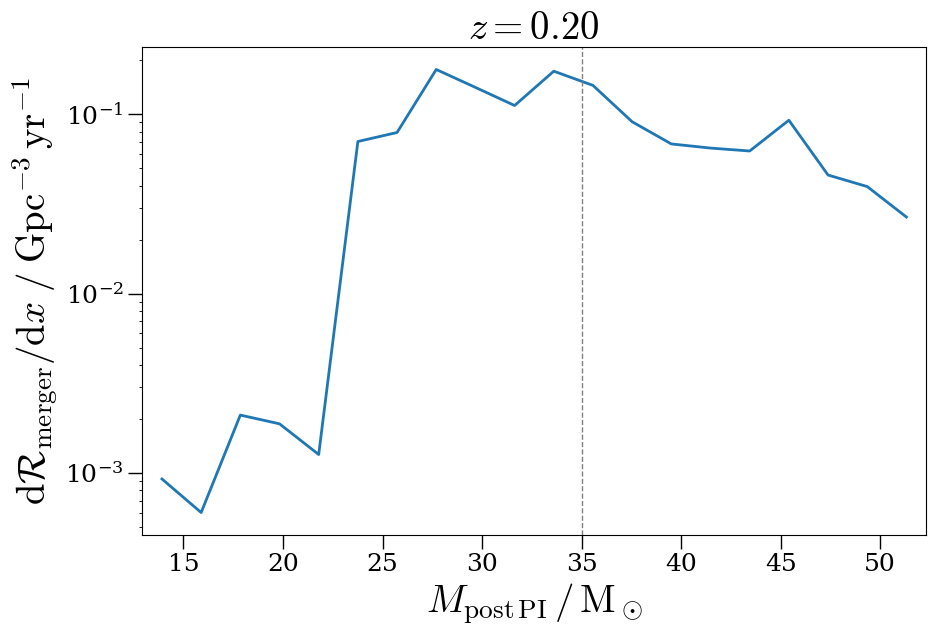

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_rate_vs_parameter(merger_df, rate_result, 'm_post_pi', redshift=0.2, ax=ax, color='C0', n_bins=20)
ax.axvline(35, ls='--', lw=1, color='gray')
fig.tight_layout()
savefig(fig, 'rate_vs_m_post_pi_z0p2')

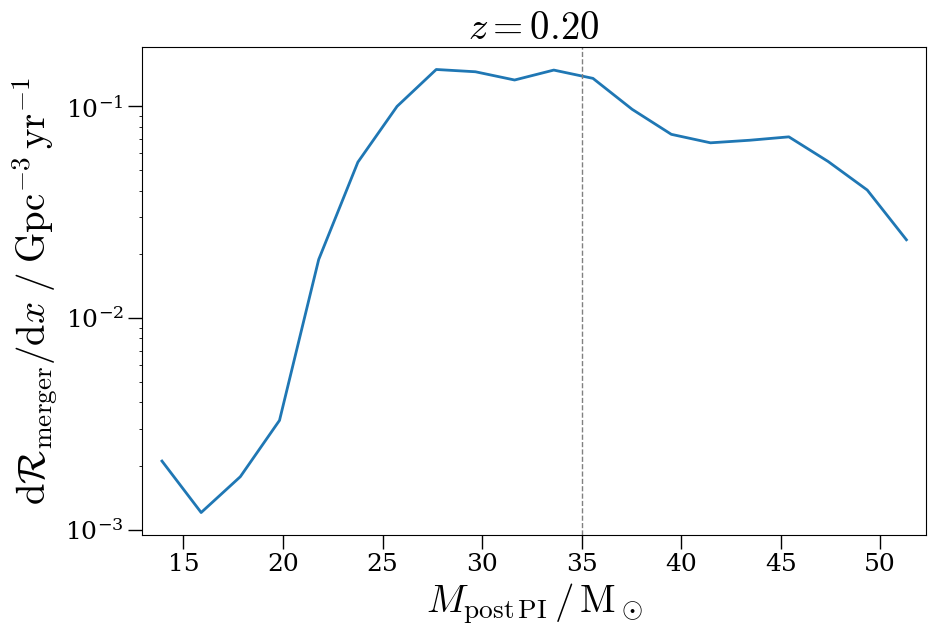

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_rate_vs_parameter(merger_df, rate_result, 'm_post_pi', redshift=0.2, ax=ax, color='C0', n_bins=20, kde=True)
ax.axvline(35, ls='--', lw=1, color='gray')
fig.tight_layout()
savefig(fig, 'rate_vs_m_post_pi_z0p2')

## 2. `m_post_pi` versus `m_f` at a fixed redshift

Both curves are drawn solid. `m_post_pi` excludes PISN systems, which leave no remnant
and are stored with `m_post_pi = 0`; `m_f` keeps every merging system.

In [18]:
def plot_mass_rate_pi_comparison(
    merger_df,
    rate_result,
    redshift,
    bins=None,
    n_bins=50,
    use_kde=False,
    bw_method=0.3,
    kde=False,
    kde_bw_scale=1.0,
    mass_columns=('m_post_pi', 'm_f'),
    colors=('C0', 'C3'),
    labels=(r'$m_\mathrm{post\,PI}$ (PI on)', r'$m_f$ (PI off)'),
    peak_mass=35.0,
    ax=None,
    show_title=True,
):
    """Plot the metallicity-integrated mass rate for two mass definitions at a fixed redshift.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with ``rate_result``.
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    redshift : float
        Redshift at which the rate is evaluated.
    bins : numpy.ndarray, optional
        Shared bin edges; spans the union of both mass columns when omitted.
    n_bins : int
        Number of bins when ``bins`` is omitted.
    use_kde, bw_method : bool, float
        Passed to :func:`differential_rate_1d`. Ignored when ``kde`` is True.
    kde : bool
        Use the continuous :class:`SmoothedRateModel` smoothing from
        :func:`plot_population_mixture` (via :func:`kde_rate_curve`) instead of
        :func:`differential_rate_1d`.
    kde_bw_scale : float
        Multiplier on the KDE bandwidth (:func:`kde_rate_curve`'s default of
        1.5), applied when ``kde`` is True. Larger values smooth away more
        structure; smaller values track the raw population more closely.
    mass_columns, colors, labels : sequence
        The two mass columns to compare and their styling.
    peak_mass : float or None
        Draw a reference line at this mass.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.
    show_title : bool
        Annotate the axes with the redshift used.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))

    # build one shared grid spanning both mass definitions
    if bins is None:
        edges = [make_bins(merger_df, c, n_bins=n_bins) for c in mass_columns]
        lo = min(e[0] for e in edges)
        hi = max(e[-1] for e in edges)
        bins = np.linspace(lo, hi, n_bins + 1)

    weights, z_used = rate_weights_at_redshift(rate_result, redshift)
    for column, color, label in zip(mass_columns, colors, labels):
        values, mask = select_parameter(merger_df, column)
        if kde:
            centers, rate = kde_rate_curve(
                values[mask], weights[mask], bins, bandwidth=1.5 * kde_bw_scale,
            )
        else:
            centers, rate = differential_rate_1d(
                values[mask], weights[mask], bins, use_kde=use_kde, bw_method=bw_method,
            )
        ax.plot(centers, rate, ls='-', color=color, label=label)

    # add labels and scales
    ax.set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
    ax.set_ylabel(rate_label('m_f'))
    ax.set_yscale('log')
    ax.set_xlim(bins[0], bins[-1])
    if peak_mass is not None:
        ax.axvline(peak_mass, ls='--', lw=1, color='gray')
    if show_title:
        ax.set_title(rf'$z = {z_used:.2f}$')
    ax.legend(frameon=False)
    return ax

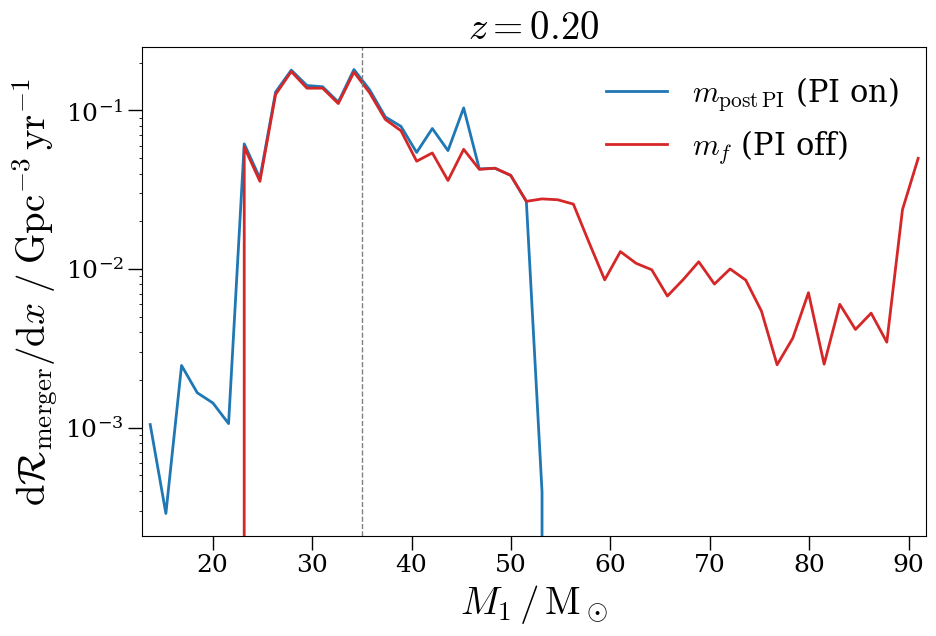

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_mass_rate_pi_comparison(merger_df, rate_result, redshift=0.2, n_bins=50, ax=ax)
fig.tight_layout()
#savefig(fig, 'rate_mass_pi_comparison_z0p2')

(0.0004, 1.0)

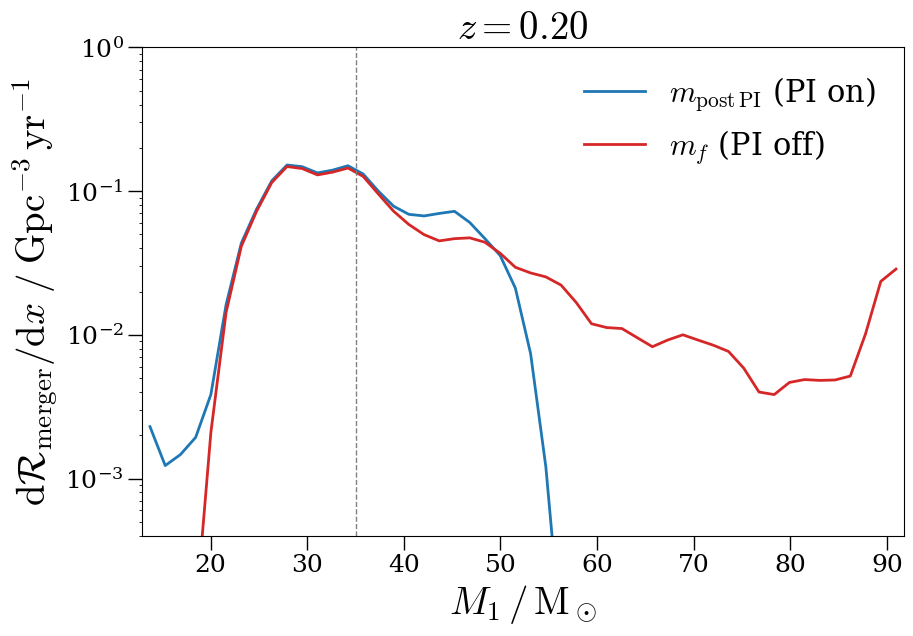

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_mass_rate_pi_comparison(merger_df, rate_result, redshift=0.2, n_bins=50, ax=ax, kde=True)
fig.tight_layout()
ax.set_ylim(4e-4, 1e0)
#savefig(fig, 'rate_mass_pi_comparison_z0p2')

## 3. Rate per metallicity bin at a fixed redshift

In [21]:
DEFAULT_METALLICITY_BINS = np.logspace(np.log10(5e-4), np.log10(0.4), 7)


def plot_rate_by_metallicity(
    merger_df,
    rate_result,
    parameter,
    redshift,
    metallicity_bins=None,
    bins=None,
    n_bins=50,
    log_x=None,
    use_kde=False,
    bw_method=0.3,
    kde=False,
    kde_bw_scale=1.0,
    drop_pisn=True,
    show_total=True,
    cmap='viridis',
    metallicity_col='z_div_zsun',
    ax=None,
    show_title=True,
):
    """Plot the differential merger rate split by metallicity bin at a fixed redshift.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with ``rate_result``.
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    parameter : str
        Any float column other than the metallicity.
    redshift : float
        Redshift at which the rate is evaluated.
    metallicity_bins : numpy.ndarray, optional
        Edges in Z/Zsun; ``DEFAULT_METALLICITY_BINS`` when omitted. The last bin
        is right-inclusive.
    bins : numpy.ndarray, optional
        Parameter bin edges, shared by all curves; built with :func:`make_bins` when omitted.
    n_bins : int
        Number of parameter bins when ``bins`` is omitted.
    log_x : bool, optional
        Bin the parameter in log10.
    use_kde, bw_method : bool, float
        Passed to :func:`differential_rate_1d`. Ignored when ``kde`` is True.
    kde : bool
        Use the continuous :class:`SmoothedRateModel` smoothing from
        :func:`plot_population_mixture` (via :func:`kde_rate_curve`) instead of
        :func:`differential_rate_1d`.
    kde_bw_scale : float
        Multiplier on the KDE bandwidth (:func:`kde_rate_curve`'s default of
        1.5), applied when ``kde`` is True. Larger values smooth away more
        structure; smaller values track the raw population more closely.
    drop_pisn : bool
        Drop PISN systems for columns in ``PARAM_MIN_POSITIVE``.
    show_total : bool
        Overlay the metallicity-integrated curve in black.
    cmap : str
        Colormap used to colour the metallicity bins.
    metallicity_col : str
        Column holding Z/Zsun.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.
    show_title : bool
        Annotate the axes with the redshift used.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if metallicity_bins is None:
        metallicity_bins = DEFAULT_METALLICITY_BINS
    if log_x is None:
        log_x = parameter in LOG_PARAMS
    if bins is None:
        bins = make_bins(merger_df, parameter, n_bins=n_bins, log=log_x, drop_pisn=drop_pisn)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))

    weights, z_used = rate_weights_at_redshift(rate_result, redshift)
    values, mask = select_parameter(merger_df, parameter, drop_pisn=drop_pisn)
    met = merger_df[metallicity_col].to_numpy(dtype=float)

    cmap_obj = plt.get_cmap(cmap)
    n_met = len(metallicity_bins) - 1

    for i in range(n_met):
        lo, hi = metallicity_bins[i], metallicity_bins[i + 1]
        in_bin = (met >= lo) & (met < hi) if i < n_met - 1 else (met >= lo) & (met <= hi)
        sel = mask & in_bin
        if not np.any(sel):
            continue
        if kde:
            try:
                centers, rate = kde_rate_curve(
                    values[sel], weights[sel], bins, log_x=log_x, bandwidth=1.5 * kde_bw_scale,
                )
            except ValueError:
                centers, rate = differential_rate_1d(
                    values[sel], weights[sel], bins,
                    log_x=log_x, use_kde=use_kde, bw_method=bw_method,
                )
        else:
            centers, rate = differential_rate_1d(
                values[sel], weights[sel], bins,
                log_x=log_x, use_kde=use_kde, bw_method=bw_method,
            )
        ax.plot(
            centers, rate, ls='-',
            color=cmap_obj(i / max(1, n_met - 1)),
            label=rf'${np.log10(lo):.1f}$–${np.log10(hi):.1f}$',
        )

    if show_total:
        if kde:
            centers, rate = kde_rate_curve(
                values[mask], weights[mask], bins, log_x=log_x, bandwidth=1.5 * kde_bw_scale,
            )
        else:
            centers, rate = differential_rate_1d(
                values[mask], weights[mask], bins,
                log_x=log_x, use_kde=use_kde, bw_method=bw_method,
            )
        ax.plot(centers, rate, ls='-', color='k', lw=3, label='total', zorder=0)

    # add labels and scales
    ax.set_xlabel(param_label(parameter))
    ax.set_ylabel(rate_label(parameter, log_x=log_x))
    ax.set_yscale('log')
    if log_x:
        ax.set_xscale('log')
    ax.set_xlim(bins[0], bins[-1])
    if show_title:
        ax.set_title(rf'$z = {z_used:.2f}$')
    ax.legend(
        frameon=False, fontsize=14, ncol=2,
        title=r'$\log_{10} Z/Z_\odot$', title_fontsize=14,
        loc='upper left', bbox_to_anchor=(1, 1)
    )
    return ax

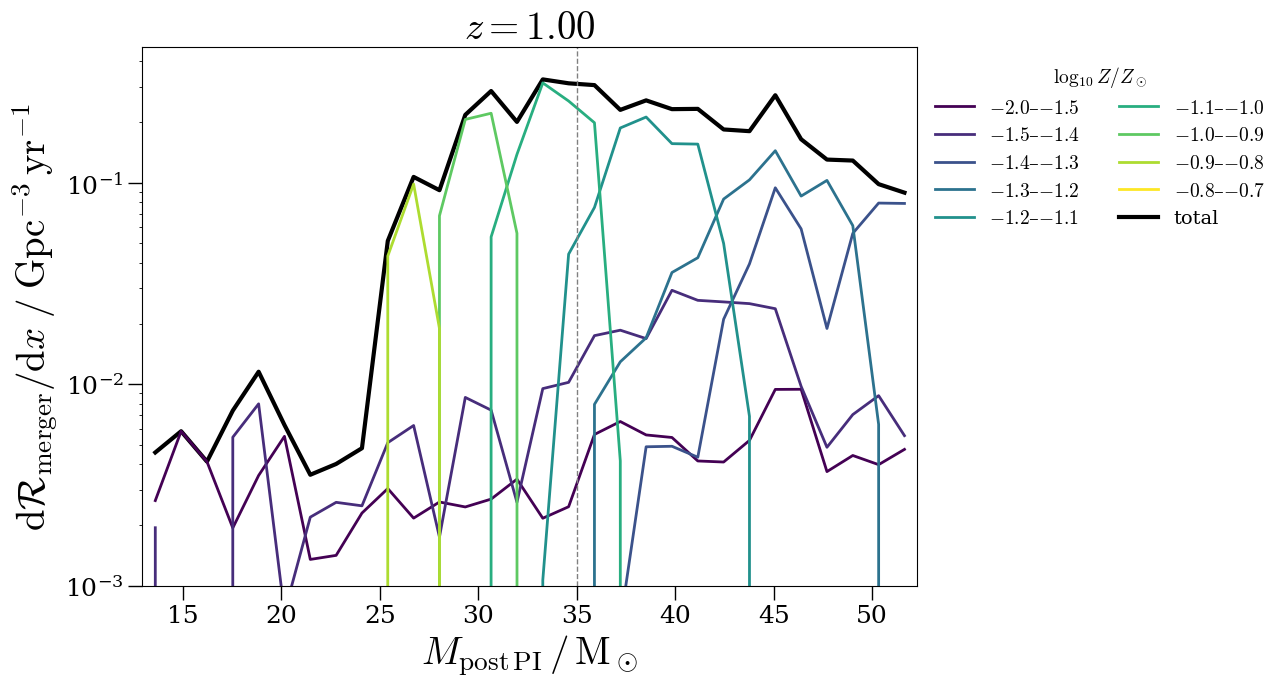

In [22]:
metallicity_bins = 10.**np.array([-2, -1.5, -1.4, -1.3, -1.2, -1.1, -1, -0.9, -0.8, -0.7])

fig, ax = plt.subplots(figsize=(10, 7))
plot_rate_by_metallicity(merger_df, rate_result, 'm_post_pi', redshift=1, ax=ax, n_bins=30, metallicity_bins=metallicity_bins)
ax.axvline(35, ls='--', lw=1, color='gray')
ax.set_ylim(1e-3)
savefig(fig, 'rate_by_metallicity_m_post_pi_z0p2')

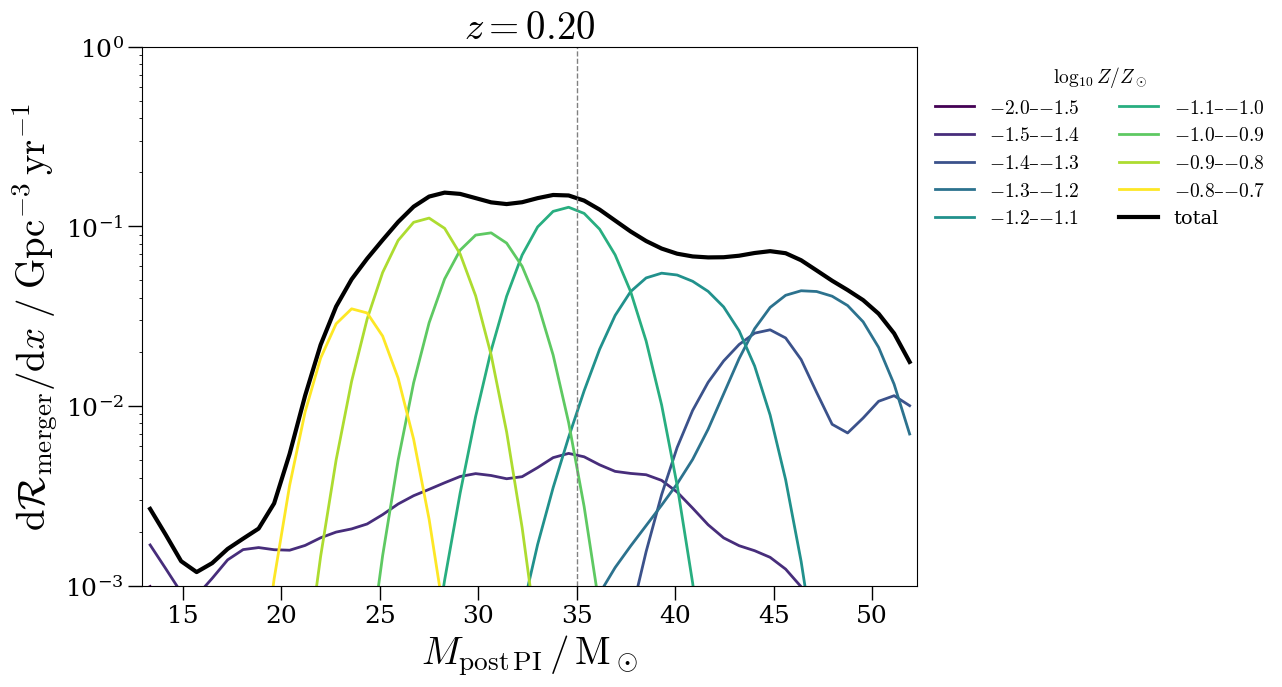

In [23]:
metallicity_bins = 10.**np.array([-2, -1.5, -1.4, -1.3, -1.2, -1.1, -1, -0.9, -0.8, -0.7])

fig, ax = plt.subplots(figsize=(10, 7))
plot_rate_by_metallicity(merger_df, rate_result, 'm_post_pi', redshift=0.2, ax=ax, n_bins=50, metallicity_bins=metallicity_bins, kde=True)
ax.axvline(35, ls='--', lw=1, color='gray')
ax.set_ylim(1e-3, 1e0)
savefig(fig, 'rate_by_metallicity_m_post_pi_z0p2')

## 4. Metallicity-integrated rate at several redshifts

In [24]:
def plot_rate_multi_redshift(
    merger_df,
    rate_result,
    parameter,
    redshifts,
    bins=None,
    n_bins=50,
    log_x=None,
    use_kde=False,
    bw_method=0.3,
    kde=False,
    kde_bw_scale=1.0,
    drop_pisn=True,
    cmap='plasma',
    colorbar=None,
    ax=None,
):
    """Plot the metallicity-integrated differential merger rate at several redshifts.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with ``rate_result``.
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    parameter : str
        Any float column other than the metallicity.
    redshifts : sequence of float
        Redshifts to overlay; each is snapped to the nearest grid value.
    bins : numpy.ndarray, optional
        Parameter bin edges, shared by all curves.
    n_bins : int
        Number of parameter bins when ``bins`` is omitted.
    log_x : bool, optional
        Bin the parameter in log10.
    use_kde, bw_method : bool, float
        Passed to :func:`differential_rate_1d`. Ignored when ``kde`` is True.
    kde : bool
        Use the continuous :class:`SmoothedRateModel` smoothing from
        :func:`plot_population_mixture` (via :func:`kde_rate_curve`) instead of
        :func:`differential_rate_1d`.
    kde_bw_scale : float
        Multiplier on the KDE bandwidth (:func:`kde_rate_curve`'s default of
        1.5), applied when ``kde`` is True. Larger values smooth away more
        structure; smaller values track the raw population more closely.
    drop_pisn : bool
        Drop PISN systems for columns in ``PARAM_MIN_POSITIVE``.
    cmap : str
        Colormap used to colour the redshifts.
    colorbar : bool, optional
        Use a colorbar instead of a legend. Defaults to True for more than five redshifts.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.

    Returns
    -------
    matplotlib.axes.Axes
    """
    redshifts = np.atleast_1d(np.asarray(redshifts, dtype=float))
    if log_x is None:
        log_x = parameter in LOG_PARAMS
    if bins is None:
        bins = make_bins(merger_df, parameter, n_bins=n_bins, log=log_x, drop_pisn=drop_pisn)
    if colorbar is None:
        colorbar = len(redshifts) > 5
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))

    values, mask = select_parameter(merger_df, parameter, drop_pisn=drop_pisn)
    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(vmin=redshifts.min(), vmax=max(redshifts.max(), redshifts.min() + 1e-6))

    for z in redshifts:
        weights, z_used = rate_weights_at_redshift(rate_result, z)
        if kde:
            centers, rate = kde_rate_curve(
                values[mask], weights[mask], bins, log_x=log_x, bandwidth=1.5 * kde_bw_scale,
            )
        else:
            centers, rate = differential_rate_1d(
                values[mask], weights[mask], bins,
                log_x=log_x, use_kde=use_kde, bw_method=bw_method,
            )
        ax.plot(centers, rate, ls='-', color=cmap_obj(norm(z)), label=rf'$z = {z_used:.2f}$')

    # add labels and scales
    ax.set_xlabel(param_label(parameter))
    ax.set_ylabel(rate_label(parameter, log_x=log_x))
    ax.set_yscale('log')
    if log_x:
        ax.set_xscale('log')
    ax.set_xlim(bins[0], bins[-1])

    if colorbar:
        mappable = ScalarMappable(norm=norm, cmap=cmap_obj)
        mappable.set_array([])
        cbar = ax.figure.colorbar(mappable, ax=ax)
        cbar.set_label(r'$z$')
    else:
        ax.legend(frameon=False, fontsize=16)
    return ax

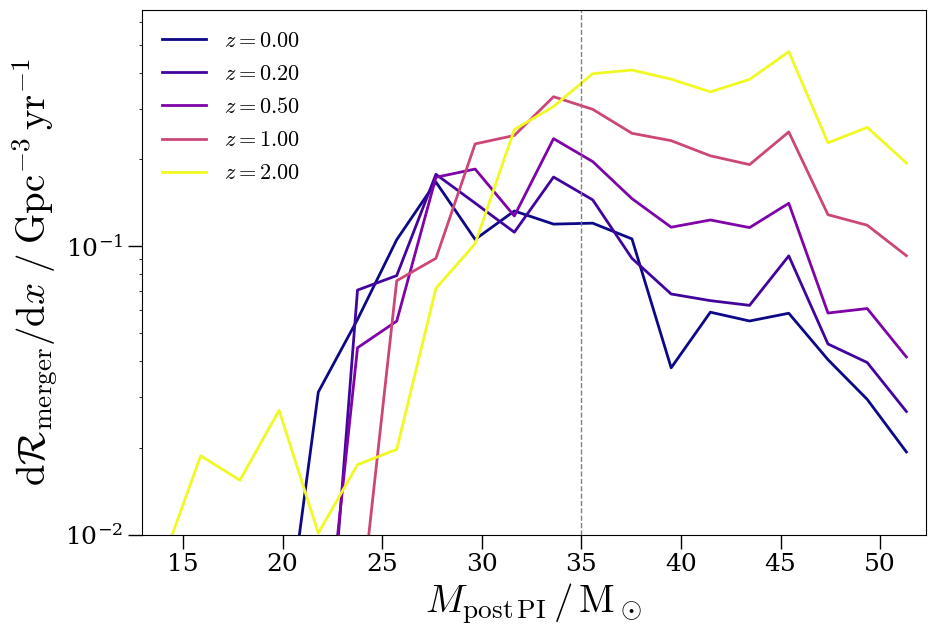

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_rate_multi_redshift(
    merger_df, rate_result, 'm_post_pi',
    redshifts=[0.0, 0.2, 0.5, 1.0, 2.0], ax=ax, n_bins=20
)
ax.axvline(35, ls='--', lw=1, color='gray')
ax.set_ylim(1e-2)
fig.tight_layout()
savefig(fig, 'rate_multi_redshift_m_post_pi')

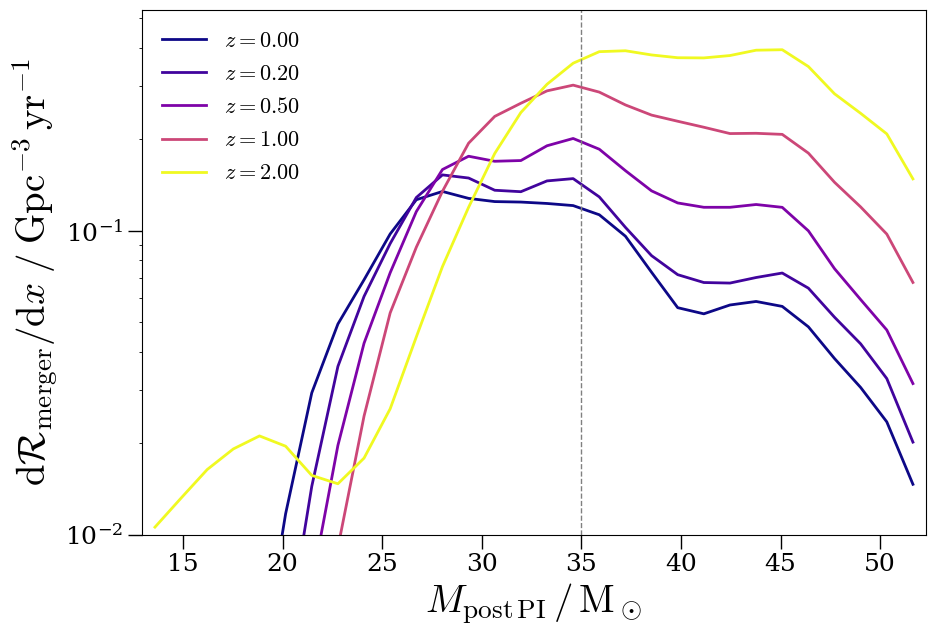

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_rate_multi_redshift(
    merger_df, rate_result, 'm_post_pi',
    redshifts=[0.0, 0.2, 0.5, 1.0, 2.0], ax=ax, n_bins=30, kde=True
)
ax.axvline(35, ls='--', lw=1, color='gray')
ax.set_ylim(1e-2)
fig.tight_layout()
savefig(fig, 'rate_multi_redshift_m_post_pi')

## 5. Two-parameter differential rate

In [27]:
def plot_rate_2d(
    merger_df,
    rate_result,
    x_parameter,
    y_parameter,
    redshift,
    x_bins=None,
    y_bins=None,
    n_bins=40,
    log_x=None,
    log_y=None,
    drop_pisn=True,
    log_color=True,
    kde=False,
    kde_bw_scale=1.0,
    cmap='magma',
    ax=None,
    show_title=True,
    colorbar=True,
):
    """Plot the differential merger rate over two parameters as a colour map.

    Parameters
    ----------
    merger_df : pandas.DataFrame
        Merging population aligned with ``rate_result``.
    rate_result : MergerRateResult
        Output of :func:`compute_population_rates`.
    x_parameter, y_parameter : str
        Any two float columns other than the metallicity.
    redshift : float
        Redshift at which the rate is evaluated.
    x_bins, y_bins : numpy.ndarray, optional
        Bin edges; built with :func:`make_bins` when omitted.
    n_bins : int
        Number of bins per axis when edges are omitted.
    log_x, log_y : bool, optional
        Bin the respective axis in log10.
    drop_pisn : bool
        Drop PISN systems for columns in ``PARAM_MIN_POSITIVE``.
    log_color : bool
        Logarithmic colour normalisation, with empty bins masked.
    kde : bool
        Weighted 2D Gaussian-KDE estimate instead of a histogram, passed to
        :func:`differential_rate_2d`.
    kde_bw_scale : float
        Multiplier on the KDE bandwidth (:func:`differential_rate_2d`'s default
        ``bw_method`` of 0.3), applied when ``kde`` is True. Larger values
        smooth away more structure; smaller values track the raw population
        more closely.
    cmap : str
        Colormap for the rate.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.
    show_title : bool
        Annotate the axes with the redshift used.
    colorbar : bool
        Attach a colorbar.

    Returns
    -------
    ax : matplotlib.axes.Axes
    mesh : matplotlib.collections.QuadMesh
    """
    if log_x is None:
        log_x = x_parameter in LOG_PARAMS
    if log_y is None:
        log_y = y_parameter in LOG_PARAMS
    if x_bins is None:
        x_bins = make_bins(merger_df, x_parameter, n_bins=n_bins, log=log_x, drop_pisn=drop_pisn)
    if y_bins is None:
        y_bins = make_bins(merger_df, y_parameter, n_bins=n_bins, log=log_y, drop_pisn=drop_pisn)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    weights, z_used = rate_weights_at_redshift(rate_result, redshift)
    x_values, x_mask = select_parameter(merger_df, x_parameter, drop_pisn=drop_pisn)
    y_values, y_mask = select_parameter(merger_df, y_parameter, drop_pisn=drop_pisn)
    sel = x_mask & y_mask

    rate, x_edges, y_edges = differential_rate_2d(
        x_values[sel], y_values[sel], weights[sel], x_bins, y_bins,
        log_x=log_x, log_y=log_y, kde=kde, bw_method=0.3 * kde_bw_scale,
    )

    plot_rate = np.ma.masked_where(rate <= 0, rate) if log_color else rate
    norm = LogNorm(vmin=plot_rate.min(), vmax=plot_rate.max()) if log_color else None
    mesh = ax.pcolormesh(x_edges, y_edges, plot_rate.T, cmap=cmap, norm=norm, shading='flat')

    # add labels and scales
    ax.set_xlabel(param_label(x_parameter))
    ax.set_ylabel(param_label(y_parameter))
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if show_title:
        ax.set_title(rf'$z = {z_used:.2f}$')
    if colorbar:
        d_x = r'\mathrm{d}\log_{10}x' if log_x else r'\mathrm{d}x'
        d_y = r'\mathrm{d}\log_{10}y' if log_y else r'\mathrm{d}y'
        cbar = ax.figure.colorbar(mesh, ax=ax)
        cbar.set_label(
            r'$\mathrm{d}^2\mathcal{R}_\mathrm{merger}/' + d_x + r'\,' + d_y
            + r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
            fontsize=18,
        )
    return ax, mesh

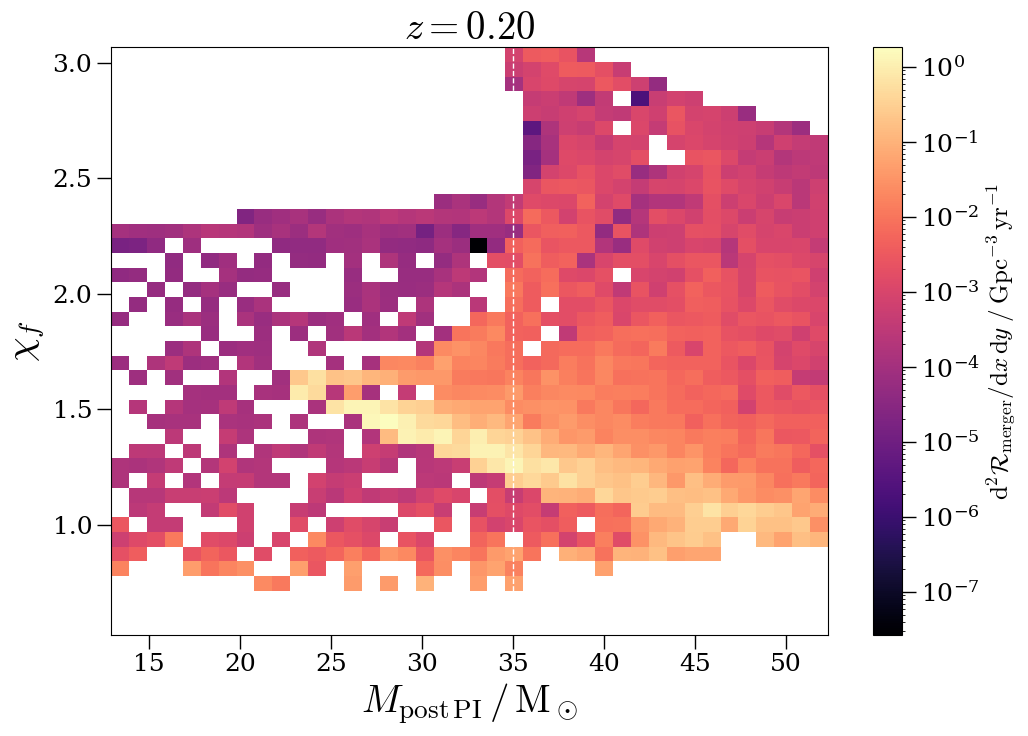

In [28]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_rate_2d(merger_df, rate_result, 'm_post_pi', 'x_f', redshift=0.2, ax=ax)
ax.axvline(35, ls='--', lw=1, color='w')
fig.tight_layout()
savefig(fig, 'rate_2d_m_post_pi_x_f_z0p2')

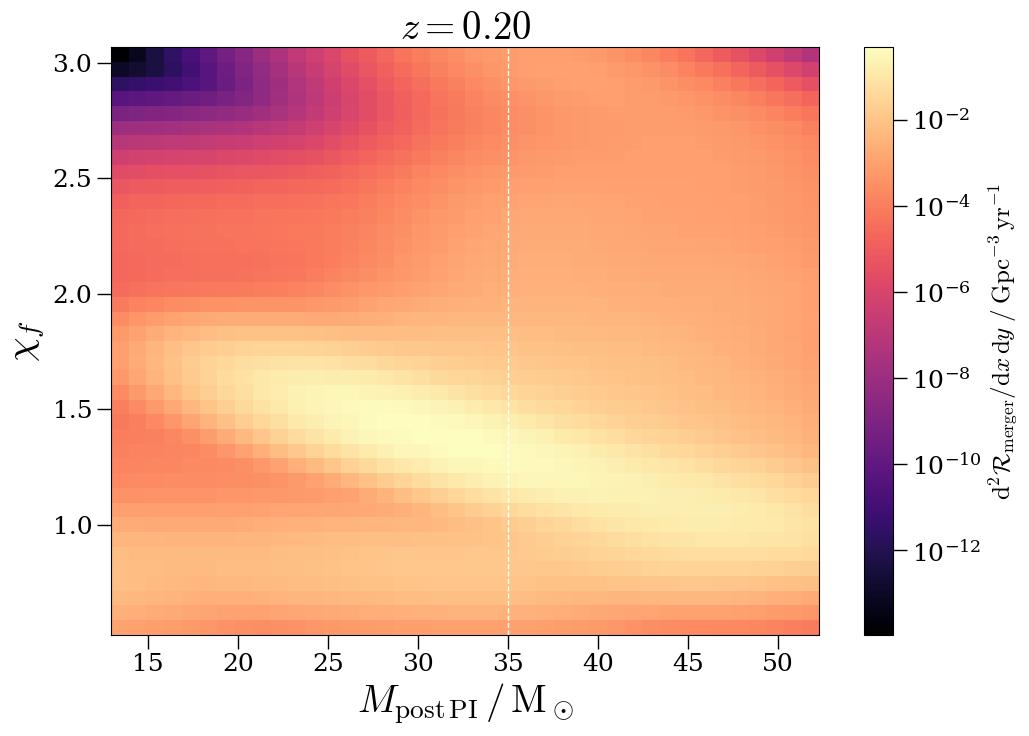

In [29]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_rate_2d(merger_df, rate_result, 'm_post_pi', 'x_f', redshift=0.2, ax=ax, kde=True, kde_bw_scale=1.5)
ax.axvline(35, ls='--', lw=1, color='w')
fig.tight_layout()
savefig(fig, 'rate_2d_m_post_pi_x_f_z0p2')

## 6. Modeling a mixed population

The histogram estimators above are too noisy to combine with a parametric model, so the
CHE rate is first smoothed with a **weighted Gaussian KDE**. The bandwidth is specified in
physical units (M$_\odot$ in linear space, dex in log space) rather than as a multiple of
Scott's factor, so it can be set to the scale of the features being preserved: the 35 M$_\odot$
pile-up is a few M$_\odot$ wide, so `bandwidth` of order 1–2 M$_\odot$ keeps it while removing
Monte-Carlo noise.

Two caveats on the KDE. A fixed bandwidth smears the sharp edges of the CHE window and of the
PISN gap, so the model should not be trusted within roughly one bandwidth of either edge.
And a Gaussian kernel leaks probability past the extremes of the sample; `space='log'` reduces
that at the low-mass end and is the better choice when the mass range spans a decade or more.

The LVK component is the **~10 M$_\odot$ peak** of the GWTC primary-mass spectrum. That peak is
not a separate term in the published model: it is produced by the low-mass smoothing
$S(m\,|\,m_\mathrm{min}, \delta_m)$ turning on against the falling first power law
$m^{-\alpha_1}$. `lvk_low_mass_peak` keeps exactly that product and drops the break and the
$\alpha_2$ branch, leaving the power law untruncated, so the high-mass end of the mixture is
a shallow $m^{-1.58}$ background rather than the steep $m^{-5.59}$ fall of the full model.
The full model stays available as `lvk_broken_power_law` for reference.

Mixtures are formed from **densities**, both renormalised over the plotted mass grid, so
`che_fraction` is exactly the CHE share of the merger rate within that grid.

In [30]:
MIXTURE_REDSHIFT = 0.2
MIXTURE_BANDWIDTH = 1.5
MIXTURE_CLAMP_LOW = 25
MIXTURE_CLAMP_FLOOR = 15.0

che_model = fit_smoothed_rate_model(
    merger_df, rate_result,
    parameter='m_post_pi', redshift=MIXTURE_REDSHIFT,
    bandwidth=MIXTURE_BANDWIDTH, space='linear',
    clamp_low=MIXTURE_CLAMP_LOW, clamp_floor=MIXTURE_CLAMP_FLOOR,
)

print(f'redshift    : {che_model.redshift}')
print(f'bandwidth   : {che_model.bandwidth} ({che_model.space} space)')
print(f'support     : {che_model.support[0]:.2f} - {che_model.support[1]:.2f} Msun')
print(f'clamp       : {MIXTURE_CLAMP_LOW} down to {MIXTURE_CLAMP_FLOOR} Msun')
print(f'total rate  : {che_model.total_rate:.4e} Gpc^-3 yr^-1')
_grid = np.linspace(1.0, 200.0, 20001)
print(f'integrated  : {np.trapezoid(che_model.rate(_grid), _grid):.4e} Gpc^-3 yr^-1'
      f'  (exceeds total rate when clamped)')

redshift    : 0.2
bandwidth   : 1.5 (linear space)
support     : 7.86 - 52.59 Msun
clamp       : 25 down to 15.0 Msun
total rate  : 2.7716e+00 Gpc^-3 yr^-1
integrated  : 3.3737e+00 Gpc^-3 yr^-1  (exceeds total rate when clamped)


In [31]:
# GWTC BROKEN POWER LAW posterior medians (Abbott et al. 2021, ApJL 913 L7;
# Abbott et al. 2023, PRX 13 011048) -- override to match the posterior you quote
LVK_LOW_MASS_PEAK = {
    'alpha_1': 1.58,
    'm_min': 3.96,
    'delta_m': 4.83,
    'm_norm_max': 87.14,
}

# mass where the two channels hand over: SMT contributes only below it, CHE only
# at and above it. None removes the split and lets both run over the full range
TRANSITION_MASS = 30

# observed BBH merger rate the SMT component is scaled to, in Gpc^-3 yr^-1.
# GWTC-3 quotes 17.9-44 at z = 0.2; set this to the value you intend to cite and
# note it is a z ~ 0.2 number, so comparisons at other redshifts need the LVK
# rate evolution rather than this constant
LVK_MERGER_RATE = 28.0

LVK_BROKEN_POWER_LAW = {
    'alpha_1': 1.58,
    'alpha_2': 5.59,
    'm_min': 3.96,
    'm_max': 87.14,
    'break_fraction': 0.43,
    'delta_m': 4.83,
}


def lvk_smoothing(m, m_min, delta_m):
    """Return the GWTC low-mass smoothing factor S(m | m_min, delta_m).

    Rises from 0 at ``m_min`` to 1 at ``m_min + delta_m``; against a falling power
    law this is what produces the ~10 Msun peak of the LVK primary-mass spectrum.
    """
    m = np.atleast_1d(np.asarray(m, dtype=float))
    s = np.zeros_like(m)
    s[m >= m_min + delta_m] = 1.0

    ramp = (m > m_min) & (m < m_min + delta_m)
    offset = m[ramp] - m_min
    with np.errstate(over='ignore'):
        f = np.exp(delta_m / offset + delta_m / (offset - delta_m))
    s[ramp] = 1.0 / (f + 1.0)
    return s


def lvk_broken_power_law(m, normalize=True, norm=1., **params):
    """Evaluate the full GWTC BROKEN POWER LAW primary-mass distribution.

    Kept as a reference for the published model; the mixture and slope comparison
    below use :func:`lvk_low_mass_peak` instead.

    Parameters
    ----------
    m : array_like
        Primary masses in solar masses.
    normalize : bool
        Divide by the numerical integral over ``[m_min, m_max]`` so the result is
        a probability density.
    **params
        Any of ``alpha_1``, ``alpha_2``, ``m_min``, ``m_max``, ``break_fraction``
        and ``delta_m``, overriding ``LVK_BROKEN_POWER_LAW``.

    Returns
    -------
    numpy.ndarray
        p(m) on the requested grid, zero outside ``[m_min, m_max]``.
    """
    unknown = set(params) - set(LVK_BROKEN_POWER_LAW)
    if unknown:
        raise TypeError(f'unknown broken-power-law parameters: {sorted(unknown)}')
    p = {**LVK_BROKEN_POWER_LAW, **params}

    m = np.atleast_1d(np.asarray(m, dtype=float))
    m_break = p['m_min'] + p['break_fraction'] * (p['m_max'] - p['m_min'])

    values = np.zeros_like(m)
    low = (m >= p['m_min']) & (m < m_break)
    high = (m >= m_break) & (m <= p['m_max'])
    values[low] = (m[low] / m_break) ** (-p['alpha_1'])
    values[high] = (m[high] / m_break) ** (-p['alpha_2'])
    values *= lvk_smoothing(m, p['m_min'], p['delta_m'])

    if normalize:
        grid = np.linspace(p['m_min'], p['m_max'], 4000)
        norm = np.trapezoid(lvk_broken_power_law(grid, normalize=False, **params), grid)
        values = values / norm
    values *= norm
    return values


def lvk_low_mass_peak(m, rate=LVK_MERGER_RATE, transition=TRANSITION_MASS, **params):
    """Evaluate the low-mass component of the GWTC primary-mass model.

    This is the first branch alone -- m^-alpha_1 times the low-mass smoothing
    S(m | m_min, delta_m) -- which is what produces the ~10 Msun peak. The break
    and the alpha_2 branch are dropped, so this stands in for the SMT channel.

    Parameters
    ----------
    m : array_like
        Primary masses in solar masses.
    rate : float or None
        Total merger rate the distribution is scaled to, in Gpc^-3 yr^-1, so the
        result is dR/dm in Gpc^-3 yr^-1 Msun^-1. ``None`` returns the raw
        unnormalised power law instead.
    transition : float or None
        Handover mass; this component is zero at and above it. ``None`` leaves the
        power law running to arbitrarily high mass, in which case ``m_norm_max``
        sets only the upper bound of the normalising integral rather than a cutoff.
    **params
        Any of ``alpha_1``, ``m_min``, ``delta_m`` and ``m_norm_max``,
        overriding ``LVK_LOW_MASS_PEAK``.

    Returns
    -------
    numpy.ndarray
        dR/dm on the requested grid, zero below ``m_min`` and at or above
        ``transition``.
    """
    unknown = set(params) - set(LVK_LOW_MASS_PEAK)
    if unknown:
        raise TypeError(f'unknown low-mass-peak parameters: {sorted(unknown)}')
    p = {**LVK_LOW_MASS_PEAK, **params}

    m = np.atleast_1d(np.asarray(m, dtype=float))
    values = np.zeros_like(m)
    above = m >= p['m_min']
    if transition is not None:
        above &= m < transition
    values[above] = (m[above] / p['m_min']) ** (-p['alpha_1'])
    values *= lvk_smoothing(m, p['m_min'], p['delta_m'])

    if rate is not None:
        # integrate over whichever range holds the whole distribution
        norm_top = p['m_norm_max'] if transition is None else max(p['m_norm_max'], transition)
        grid = np.linspace(p['m_min'], norm_top, 4000)
        norm = np.trapezoid(
            lvk_low_mass_peak(grid, rate=None, transition=transition, **params), grid
        )
        values = values * (rate / norm)
    return values

### 6.1 Mixture of the CHE model and the LVK broken power law

In [32]:
def channel_rates(m, che_model, che_scale=1.0, transition=TRANSITION_MASS, lvk_kwargs=None):
    """Return the CHE and SMT differential merger rates on a mass grid.

    Both carry their own normalisation: the CHE model the rate from the cosmic
    integration, scaled by ``che_scale``, and the SMT power law the observed LVK
    rate. Nothing is renormalised on the grid, so the two are directly comparable
    and cutting either channel genuinely removes rate.

    Parameters
    ----------
    m : array_like
        Mass grid.
    che_model : SmoothedRateModel
        Smoothed CHE rate model.
    che_scale : float
        Multiplier on the CHE rate, for exploring how much of it the channel
        actually contributes.
    transition : float or None
        Handover mass. SMT is zero at and above it, CHE is zero below it; ``None``
        lets both channels run over the whole grid.
    lvk_kwargs : dict, optional
        Overrides passed to :func:`lvk_low_mass_peak`, including ``rate``.

    Returns
    -------
    r_che, r_smt : numpy.ndarray
        dR/dm of each channel in Gpc^-3 yr^-1 Msun^-1.
    """
    m = np.atleast_1d(np.asarray(m, dtype=float))
    r_che = che_scale * che_model.rate(m)
    r_smt = lvk_low_mass_peak(m, **{'transition': transition, **(lvk_kwargs or {})})

    # CHE takes over only at and above the handover mass
    if transition is not None:
        r_che = np.where(m >= transition, r_che, 0.0)
    return r_che, r_smt


def mixture_rate(m, che_model, che_scale=1.0, transition=TRANSITION_MASS, lvk_kwargs=None):
    """Total differential merger rate of the CHE and SMT channels combined.

    Parameters
    ----------
    m : array_like
        Mass grid.
    che_model : SmoothedRateModel
        Smoothed CHE rate model.
    che_scale : float
        Multiplier on the CHE rate.
    transition : float or None
        Handover mass, passed to :func:`channel_rates`.
    lvk_kwargs : dict, optional
        Overrides passed to :func:`lvk_low_mass_peak`.

    Returns
    -------
    numpy.ndarray
        dR/dm of the summed channels in Gpc^-3 yr^-1 Msun^-1.
    """
    r_che, r_smt = channel_rates(
        m, che_model, che_scale=che_scale, transition=transition, lvk_kwargs=lvk_kwargs,
    )
    return r_che + r_smt

def plot_population_mixture(
    che_model,
    mass_grid=None,
    che_scales=(0.0, 0.5, 1.0),
    transition=TRANSITION_MASS,
    lvk_kwargs=None,
    cmap='viridis',
    ylim_decades=6.0,
    peak_mass=35.0,
    ax=None,
    show_title=True,
):
    """Plot the summed CHE + SMT merger rate for a range of CHE scalings.

    Parameters
    ----------
    che_model : SmoothedRateModel
        Smoothed CHE rate model, from :func:`fit_smoothed_rate_model`.
    mass_grid : array_like, optional
        Masses to evaluate on; a 500-point grid over 5-100 Msun when omitted.
    che_scales : sequence of float
        CHE rate multipliers to overlay. A scaling of 0 leaves the SMT channel alone.
    transition : float or None
        Handover mass, passed to :func:`channel_rates`.
    lvk_kwargs : dict, optional
        Overrides passed to :func:`lvk_low_mass_peak`.
    cmap : str
        Colormap used to colour the scalings.
    ylim_decades : float or None
        Limit the log y-axis to this many decades below the highest curve. The KDE
        keeps Gaussian tails far outside the CHE support, which otherwise stretch
        the axis over tens of meaningless decades.
    peak_mass : float or None
        Draw a reference line at this mass.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.
    show_title : bool
        Annotate the axes with the redshift of the CHE model.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if mass_grid is None:
        mass_grid = np.linspace(5.0, 100.0, 500)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))

    mass_grid = np.asarray(mass_grid, dtype=float)
    scales = np.atleast_1d(np.asarray(che_scales, dtype=float))
    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(vmin=scales.min(), vmax=max(scales.max(), 1e-6))

    curves = []
    for scale in scales:
        mixed = mixture_rate(
            mass_grid, che_model, scale, transition=transition, lvk_kwargs=lvk_kwargs,
        )
        curves.append(mixed)
        ax.plot(
            mass_grid, mixed, ls='-', color=cmap_obj(norm(scale)),
            label=rf'${scale:g}\times$ CHE $+$ SMT',
        )

    # add labels and scales
    ax.set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
    ax.set_ylabel(rate_label('m_f'))
    ax.set_yscale('log')
    ax.set_xlim(mass_grid[0], mass_grid[-1])
    if ylim_decades is not None and curves:
        # keep the axis off the KDE's far tails
        top = max(np.nanmax(curve) for curve in curves)
        if top > 0:
            ax.set_ylim(top * 10.0 ** (-ylim_decades), top * 2.0)
    if transition is not None:
        ax.axvline(transition, ls=':', lw=1.5, color='gray')
        ax.text(transition, ax.get_ylim()[1], f'${transition:.0f}\,\mathrm{{M}}_\odot$', va='top', ha='right', color='gray', fontsize=18)
    if peak_mass is not None:
        ax.axvline(peak_mass, ls='--', lw=1, color='gray')
        ax.text(peak_mass, ax.get_ylim()[1], f'${peak_mass:.0f}\,\mathrm{{M}}_\odot$', va='top', ha='left', color='gray', fontsize=18)
    if show_title and che_model.redshift is not None:
        ax.set_title(rf'$z = {che_model.redshift:.2f}$')
    ax.legend(frameon=False, fontsize=16)
    return ax

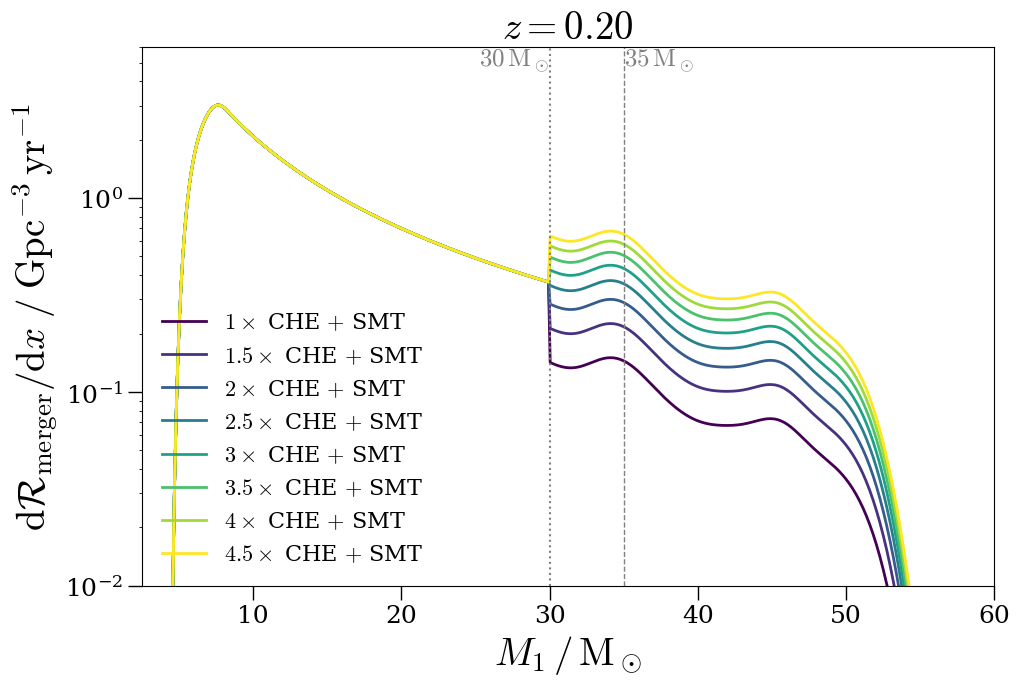

In [33]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_population_mixture(
    che_model,
    mass_grid=np.linspace(2.5, 60.0, 500),
    che_scales=np.arange(1, 5, 0.5),
    ax=ax,
)
ax.set_ylim(1e-2)
savefig(fig, 'population_mixture_che_lvk')

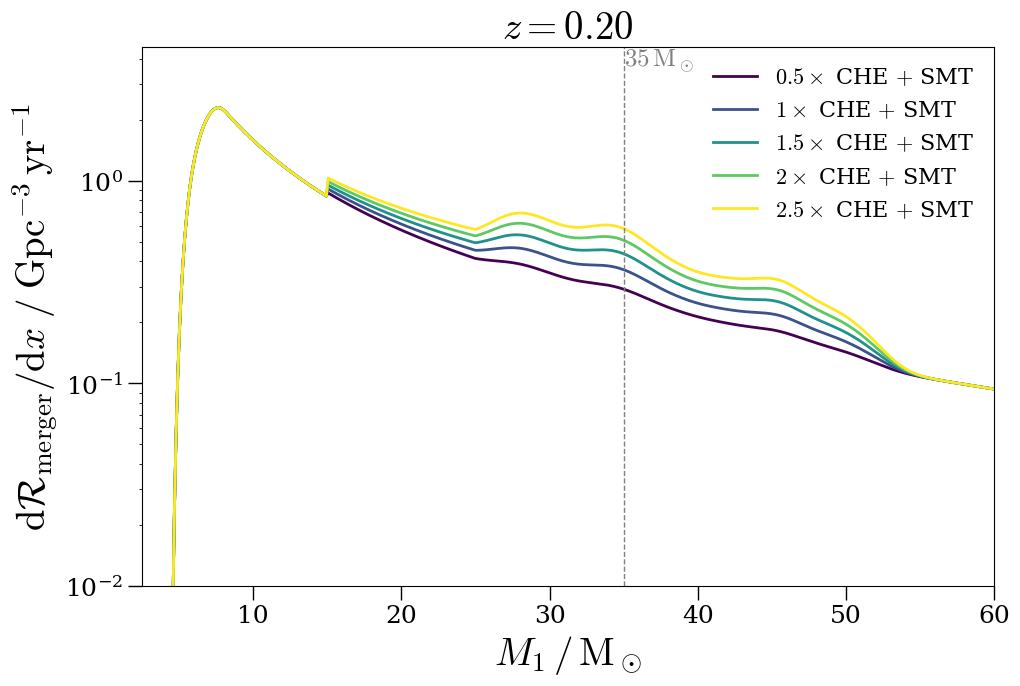

In [34]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_population_mixture(
    che_model,
    mass_grid=np.linspace(2.5, 60.0, 500),
    che_scales=np.arange(0.5, 3, 0.5),
    ax=ax,
    transition=None,
)
ax.set_ylim(1e-2)
savefig(fig, 'population_mixture_che_lvk')

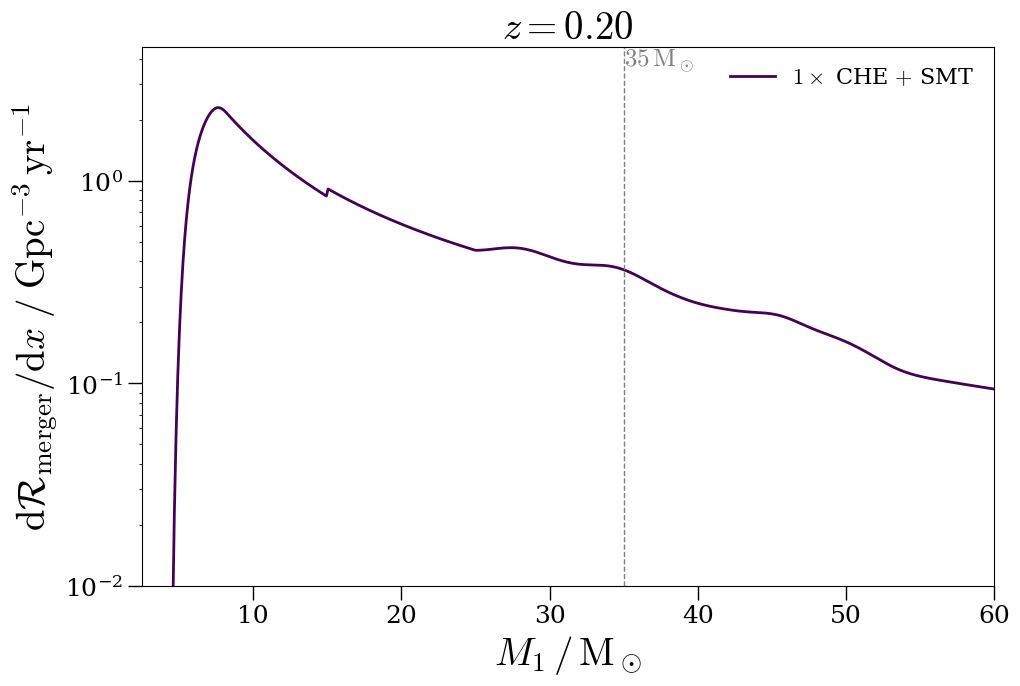

In [35]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_population_mixture(
    che_model,
    mass_grid=np.linspace(2.5, 60.0, 500),
    che_scales=[1],
    ax=ax,
    transition=None
)
ax.set_ylim(1e-2)
savefig(fig, 'population_mixture_che_lvk')

### 6.2 CHE and SMT rate curves, without mixing

The two channels drawn as separate curves, each carrying its own rate normalisation:
CHE the rate from the cosmic integration, SMT the observed `LVK_MERGER_RATE`. They hand
over at `transition` — SMT is null at and above it, CHE is null below it — so the two
curves never overlap in mass.

In [36]:
def plot_channel_comparison(
    che_model,
    mass_grid=None,
    lvk_kwargs=None,
    che_scale=1.0,
    transition=TRANSITION_MASS,
    che_color='C0',
    smt_color='C3',
    ylim_decades=6.0,
    show_transition=True,
    peak_mass=35.0,
    ax=None,
    show_title=True,
):
    """Plot the CHE and SMT merger-rate curves separately, without mixing them.

    Each channel carries its own rate normalisation via :func:`channel_rates`, so
    the curves are absolute and directly comparable.

    Parameters
    ----------
    che_model : SmoothedRateModel
        Smoothed CHE rate model; pass the paired m1 model to compare that instead.
    mass_grid : array_like, optional
        Masses to evaluate on; a 500-point grid over 5-100 Msun when omitted.
    lvk_kwargs : dict, optional
        Overrides passed to :func:`lvk_low_mass_peak`, including ``rate``.
    che_scale : float
        Multiplier on the CHE rate.
    transition : float or None
        Handover mass. SMT is zero at and above it, CHE is zero below it.
    che_color, smt_color : str
        Line colours.
    ylim_decades : float or None
        Limit the log y-axis to this many decades below the highest curve.
    show_transition : bool
        Mark the handover mass with a vertical line.
    peak_mass : float or None
        Draw a reference line at this mass.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.
    show_title : bool
        Annotate the axes with the redshift of the CHE model.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if mass_grid is None:
        mass_grid = np.linspace(5.0, 100.0, 500)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))

    mass_grid = np.asarray(mass_grid, dtype=float)

    p_che, p_smt = channel_rates(
        mass_grid, che_model, che_scale=che_scale,
        transition=transition, lvk_kwargs=lvk_kwargs,
    )

    ax.plot(mass_grid, p_che, ls='-', color=che_color, label='CHE')
    ax.plot(mass_grid, p_smt, ls='-', color=smt_color, label='SMT (power law)')

    # add labels and scales
    ax.set_xlabel(r'$M_1\,/\,\mathrm{M}_\odot$')
    ax.set_ylabel(rate_label('m_f'))
    ax.set_yscale('log')
    ax.set_xlim(mass_grid[0], mass_grid[-1])
    if ylim_decades is not None:
        top = max(np.nanmax(p_che), np.nanmax(p_smt))
        if top > 0:
            ax.set_ylim(top * 10.0 ** (-ylim_decades), top * 2.0)
    if show_transition and transition is not None:
        ax.axvline(transition, ls=':', lw=1.5, color='gray')
    if peak_mass is not None:
        ax.axvline(peak_mass, ls='--', lw=1, color='gray')
    if show_title and che_model.redshift is not None:
        ax.set_title(rf'$z = {che_model.redshift:.2f}$')
    ax.legend(frameon=False, fontsize=16)
    return ax

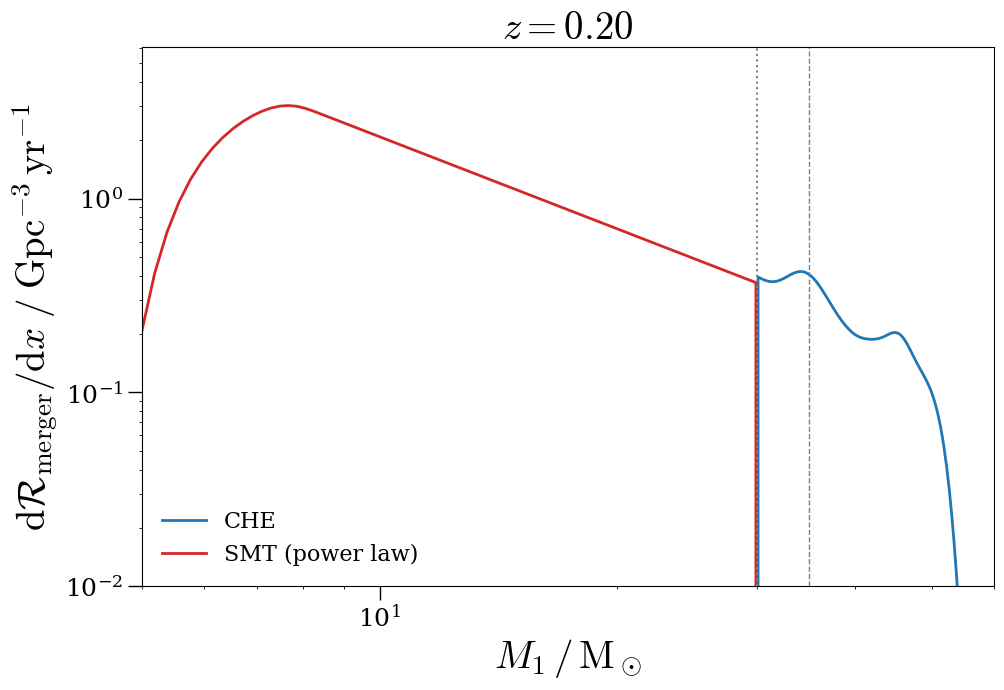

In [37]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_channel_comparison(
    che_model,
    mass_grid=np.linspace(5.0, 100.0, 500),
    transition=30,
    ax=ax,
    che_scale=2.8,
)
ax.set_xlim(5, 60)
ax.set_xscale('log')
ax.set_ylim(1e-2)
savefig(fig, 'channel_comparison_che_smt')

### 6.3 2-D Merger Rate as a Function of Metallicity and Delay Time


In [286]:
def differential_rate_2d(
    x_values, y_values, weights, x_bins, y_bins,
    log_x=False, log_y=False, kde=False, bw_method=0.3,
):
    """Compute the differential merger rate over a two-parameter bin grid.

    Parameters
    ----------
    x_values, y_values : numpy.ndarray
        Parameter values, one per system.
    weights : numpy.ndarray
        Per-system rate densities at the chosen redshift.
    x_bins, y_bins : numpy.ndarray
        Bin edges in linear parameter units.
    log_x, log_y : bool
        Bin the respective axis in log10.
    kde : bool
        Weighted 2D Gaussian-KDE estimate, evaluated at bin centres, instead of
        a histogram.
    bw_method : float
        KDE bandwidth, ignored when ``kde`` is False.

    Returns
    -------
    rate : numpy.ndarray
        Shape ``(len(x_bins) - 1, len(y_bins) - 1)``, the rate per unit bin area.
    x_edges, y_edges : numpy.ndarray
        Bin edges actually used, in linear parameter units.
    """
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    w = np.asarray(weights, dtype=float)
    x_edges = np.asarray(x_bins, dtype=float)
    y_edges = np.asarray(y_bins, dtype=float)

    x_used, x_bins_used = (np.log10(x), np.log10(x_edges)) if log_x else (x, x_edges)
    y_used, y_bins_used = (np.log10(y), np.log10(y_edges)) if log_y else (y, y_edges)

    valid = np.isfinite(x_used) & np.isfinite(y_used) & np.isfinite(w)
    w = np.where(w < 0, 0.0, w)

    if kde:
        x_centers = 0.5 * (x_bins_used[:-1] + x_bins_used[1:])
        y_centers = 0.5 * (y_bins_used[:-1] + y_bins_used[1:])
        xx, yy = np.meshgrid(x_centers, y_centers, indexing='ij')
        kernel = gaussian_kde(
            np.vstack([x_used[valid], y_used[valid]]), weights=w[valid], bw_method=bw_method,
        )
        density = kernel(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        rate = density * w[valid].sum()
    else:
        counts, _, _ = np.histogram2d(
            x_used[valid], y_used[valid],
            bins=[x_bins_used, y_bins_used],
            weights=w[valid],
        )
        area = np.outer(np.diff(x_bins_used), np.diff(y_bins_used))
        rate = counts / area
    return rate, x_edges, y_edges

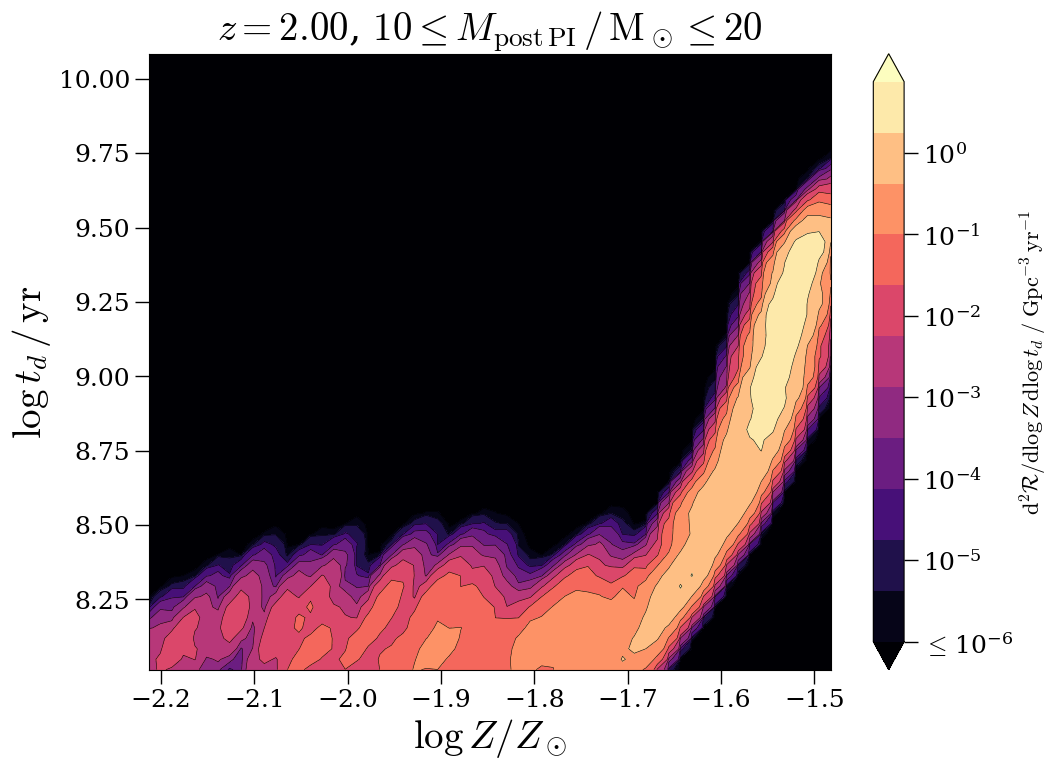

In [287]:
# --- User settings ---
VAR = 'm_post_pi'               # population column to slice on
MASS_SLICE = (10, 20)            # mass window [Msun]
REDSHIFT_2D = 2                # observation redshift
N_BINS_2D = 60                   # KDE evaluation grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex; both axes are log-spaced)

# contour settings
RATE_FLOOR = 1e-6                # minimum rate density shown [Gpc^-3 yr^-1 dex^-2]
N_LEVELS = 12                   # contour levels; None -> 2 levels per decade
FILLED = True                    # filled contours (contourf) vs line-only (contour)
CONTOUR_CMAP = 'magma'           # colormap
CONTOUR_LINEWIDTHS = 0.4
XLIM = None                      # x-axis limits; None -> auto
YLIM = None                      # y-axis limits; None -> auto
RATE_CEIL = None                 # max rate density shown; None -> auto from data

# --- Per-system rate weights at the chosen redshift ---
weights_2d, z_used_2d = rate_weights_at_redshift(rate_result, REDSHIFT_2D)

# --- Mass slice ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
w_cut = weights_2d[mass_cut]

# --- Bin edges and 2-D KDE ---
log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)

rate_2d, _, _ = differential_rate_2d(
    log_z, log_td, w_cut,
    log_z_bins, log_td_bins,
    log_x=False, log_y=False,
    kde=True, bw_method=KDE_BW_2D,
)

# --- Contour plot ---
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

rate_plot = np.where(rate_2d > 0, rate_2d, np.nan)
vmax = RATE_CEIL if RATE_CEIL is not None else np.nanmax(rate_plot)
_n_decades = np.log10(vmax) - np.log10(RATE_FLOOR)
_n_levels = N_LEVELS if N_LEVELS is not None else max(int(np.round(2 * _n_decades)) + 1, 3)
levels = np.logspace(np.log10(RATE_FLOOR), np.log10(vmax), _n_levels)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor(plt.get_cmap(CONTOUR_CMAP)(0.0))
if FILLED:
    cf = ax.contourf(log_z_c, log_td_c, rate_plot.T, levels=levels,
                      cmap=CONTOUR_CMAP, norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
                      extend='both')
if CONTOUR_LINEWIDTHS > 0:
    ax.contour(log_z_c, log_td_c, rate_plot.T, levels=levels,
               colors='k' if FILLED else None,
               cmap=None if FILLED else CONTOUR_CMAP,
               norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
               linewidths=CONTOUR_LINEWIDTHS)

ax.set_xlabel(r'$\log Z/Z_\odot$')
ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
ax.set_title(
    rf'$z = {z_used_2d:.2f}$, '
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$'
)

from matplotlib.ticker import LogLocator, LogFormatterMathtext, FuncFormatter
cbar = fig.colorbar(cf if FILLED else ax.collections[0], ax=ax)
cbar.locator = LogLocator(base=10, numticks=8)
_base_fmt = LogFormatterMathtext()
def _leq_fmt(x, pos, _bf=_base_fmt, _fl=RATE_FLOOR):
    s = _bf(x, pos)
    return (r'$\leq\,$' + s) if (x > 0 and abs(np.log10(x) - np.log10(_fl)) < 0.05) else s
cbar.formatter = FuncFormatter(_leq_fmt)
cbar.update_ticks()
cbar.set_label(
    r'$\mathrm{d}^2\mathcal{R}'
    r'/\mathrm{d}\log Z\,\mathrm{d}\log t_d'
    r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
    fontsize=16,
)
savefig(fig, f'rate_2d_logz_logtd_{VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}')

/tmp/ipykernel_1465247/796304369.py:94: RuntimeWarning: invalid value encountered in divide
  _ov_mean = np.where(_ov_den > 0, _ov_num / _ov_den, np.nan)
/tmp/ipykernel_1465247/796304369.py:125: RuntimeWarning: invalid value encountered in divide
  _ov2_mean = np.where(_ov2_den > 0, _ov2_num / _ov2_den, np.nan)


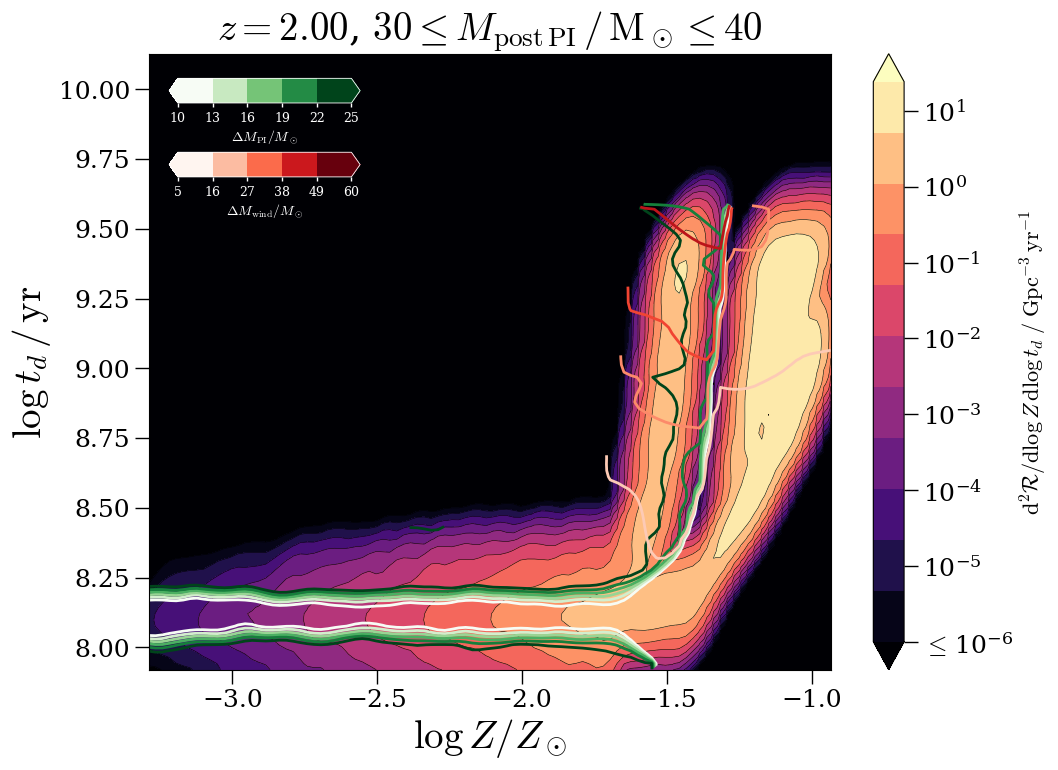

In [288]:
# --- User settings ---
VAR = 'm_post_pi'               # population column to slice on
MASS_SLICE = (30, 40)            # mass window [Msun]
REDSHIFT_2D = 2                  # observation redshift
N_BINS_2D = 100                   # KDE evaluation grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex; both axes are log-spaced)

# rate contour settings (filled background)
RATE_FLOOR = 1e-6                # minimum rate density shown [Gpc^-3 yr^-1 dex^-2]
N_LEVELS = 12                    # contour levels; None -> 2 levels per decade
CONTOUR_CMAP = 'magma'           # colormap
CONTOUR_LINEWIDTHS = 0.4         # rate contour edge width (0 to suppress)
XLIM = None                      # axis / bin limits; None -> auto
YLIM = None
RATE_CEIL = None                 # max rate density; None -> auto

# overlay variable contour settings
OVERLAY_VAR = 'pi_delta_m'      # column to overlay as contour lines; '' -> disable
OVERLAY_SMOOTH = 1.5             # Gaussian smoothing (bin units)
OVERLAY_N_LEVELS = 6             # number of overlay contour levels
OVERLAY_CMAP = 'Greens'            # overlay colormap
OVERLAY_ALPHA = 1             # line opacity
OVERLAY_LW = 2                 # line width
OVERLAY_VMIN = 10              # overlay variable range; None -> auto
OVERLAY_VMAX = 25
OVERLAY_LABEL = r'$\Delta M_{\rm PI}/M_\odot$'             # colorbar label; None -> use param_label

# second overlay (same style defaults as overlay 1)
OVERLAY2_VAR = 'wind_delta_m'    # column; '' -> disable second overlay
OVERLAY2_SMOOTH = OVERLAY_SMOOTH
OVERLAY2_N_LEVELS = OVERLAY_N_LEVELS
OVERLAY2_CMAP = 'Reds'
OVERLAY2_ALPHA = OVERLAY_ALPHA
OVERLAY2_LW = OVERLAY_LW
OVERLAY2_VMIN = 5
OVERLAY2_VMAX = 60
OVERLAY2_LABEL = r'$\Delta M_{\rm wind}/M_\odot$'            # None -> use param_label

# --- Per-system rate weights at the chosen redshift ---
weights_2d, z_used_2d = rate_weights_at_redshift(rate_result, REDSHIFT_2D)

# --- Mass slice ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
w_cut = weights_2d[mass_cut]

# --- Bin edges and 2-D KDE ---
log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)

rate_2d, _, _ = differential_rate_2d(
    log_z, log_td, w_cut,
    log_z_bins, log_td_bins,
    log_x=False, log_y=False,
    kde=True, bw_method=KDE_BW_2D,
)

# --- Rate contour plot ---
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

rate_plot = np.where(rate_2d > 0, rate_2d, np.nan)
vmax = RATE_CEIL if RATE_CEIL is not None else np.nanmax(rate_plot)
_n_decades = np.log10(vmax) - np.log10(RATE_FLOOR)
_n_levels = N_LEVELS if N_LEVELS is not None else max(int(np.round(2 * _n_decades)) + 1, 3)
levels = np.logspace(np.log10(RATE_FLOOR), np.log10(vmax), _n_levels)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor(plt.get_cmap(CONTOUR_CMAP)(0.0))
cf = ax.contourf(log_z_c, log_td_c, rate_plot.T, levels=levels,
                  cmap=CONTOUR_CMAP, norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
                  extend='both')
if CONTOUR_LINEWIDTHS > 0:
    ax.contour(log_z_c, log_td_c, rate_plot.T, levels=levels,
               colors='k', norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
               linewidths=CONTOUR_LINEWIDTHS)

# --- Overlay: variable contour lines ---
from scipy.ndimage import gaussian_filter

from matplotlib.colors import BoundaryNorm

# inset colorbar for overlay variable (top-left); empty OVERLAY_VAR disables
if OVERLAY_VAR:
    c_vals = merger_df[OVERLAY_VAR].to_numpy()[mass_cut]
    _ov_num, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=w_cut * c_vals)
    _ov_den, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=w_cut)
    if OVERLAY_SMOOTH > 0:
        _ov_num = gaussian_filter(np.nan_to_num(_ov_num), sigma=OVERLAY_SMOOTH)
        _ov_den = gaussian_filter(np.nan_to_num(_ov_den), sigma=OVERLAY_SMOOTH)
    _ov_mean = np.where(_ov_den > 0, _ov_num / _ov_den, np.nan)

    _ov_vmin = OVERLAY_VMIN if OVERLAY_VMIN is not None else np.nanmin(_ov_mean)
    _ov_vmax = OVERLAY_VMAX if OVERLAY_VMAX is not None else np.nanmax(_ov_mean)
    _ov_levels = np.linspace(_ov_vmin, _ov_vmax, OVERLAY_N_LEVELS)
    _ov_norm = Normalize(vmin=_ov_levels[0], vmax=_ov_levels[-1])
    cs_ov = ax.contour(log_z_c, log_td_c, _ov_mean.T, levels=_ov_levels,
                        cmap=OVERLAY_CMAP, norm=_ov_norm,
                        alpha=OVERLAY_ALPHA, linewidths=OVERLAY_LW)

    # inset colorbar for overlay variable (top-left)
    _cax = ax.inset_axes([0.03, 0.92, 0.28, 0.04])
    _ov_bnorm = BoundaryNorm(_ov_levels, ncolors=plt.get_cmap(OVERLAY_CMAP).N, clip=False)
    _sm = ScalarMappable(norm=_ov_bnorm, cmap=OVERLAY_CMAP)
    _ov_cbar = fig.colorbar(_sm, cax=_cax, orientation='horizontal',
                             boundaries=_ov_levels, ticks=_ov_levels,
                             extend='both', extendfrac=0.05)
    _ov_cbar.ax.tick_params(labelsize=9, colors='white', length=3)
    _ov_cbar.outline.set_edgecolor('white')
    _ov_cbar.outline.set_linewidth(0.6)
    _ov_label = OVERLAY_LABEL or param_label(OVERLAY_VAR)
    _ov_cbar.set_label(_ov_label, fontsize=10, color='white', labelpad=2)

# --- Overlay 2: second variable contour lines ---
if OVERLAY2_VAR:
    c2_vals = merger_df[OVERLAY2_VAR].to_numpy()[mass_cut]
    _ov2_num, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=w_cut * c2_vals)
    _ov2_den, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=w_cut)
    if OVERLAY2_SMOOTH > 0:
        _ov2_num = gaussian_filter(np.nan_to_num(_ov2_num), sigma=OVERLAY2_SMOOTH)
        _ov2_den = gaussian_filter(np.nan_to_num(_ov2_den), sigma=OVERLAY2_SMOOTH)
    _ov2_mean = np.where(_ov2_den > 0, _ov2_num / _ov2_den, np.nan)

    _ov2_vmin = OVERLAY2_VMIN if OVERLAY2_VMIN is not None else np.nanmin(_ov2_mean)
    _ov2_vmax = OVERLAY2_VMAX if OVERLAY2_VMAX is not None else np.nanmax(_ov2_mean)
    _ov2_levels = np.linspace(_ov2_vmin, _ov2_vmax, OVERLAY2_N_LEVELS)
    _ov2_norm = Normalize(vmin=_ov2_levels[0], vmax=_ov2_levels[-1])
    ax.contour(log_z_c, log_td_c, _ov2_mean.T, levels=_ov2_levels,
               cmap=OVERLAY2_CMAP, norm=_ov2_norm,
               alpha=OVERLAY2_ALPHA, linewidths=OVERLAY2_LW)

    _cax2 = ax.inset_axes([0.03, 0.80, 0.28, 0.04])
    _ov2_bnorm = BoundaryNorm(_ov2_levels, ncolors=plt.get_cmap(OVERLAY2_CMAP).N, clip=False)
    _sm2 = ScalarMappable(norm=_ov2_bnorm, cmap=OVERLAY2_CMAP)
    _ov2_cbar = fig.colorbar(_sm2, cax=_cax2, orientation='horizontal',
                              boundaries=_ov2_levels, ticks=_ov2_levels,
                              extend='both', extendfrac=0.05)
    _ov2_cbar.ax.tick_params(labelsize=9, colors='white', length=3)
    _ov2_cbar.outline.set_edgecolor('white')
    _ov2_cbar.outline.set_linewidth(0.6)
    _ov2_label = OVERLAY2_LABEL or param_label(OVERLAY2_VAR)
    _ov2_cbar.set_label(_ov2_label, fontsize=10, color='white', labelpad=2)

ax.set_xlabel(r'$\log Z/Z_\odot$')
ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
ax.set_title(
    rf'$z = {z_used_2d:.2f}$, '
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$'
)

from matplotlib.ticker import LogLocator, LogFormatterMathtext, FuncFormatter
cbar = fig.colorbar(cf, ax=ax)
cbar.locator = LogLocator(base=10, numticks=8)
_base_fmt = LogFormatterMathtext()
def _leq_fmt(x, pos, _bf=_base_fmt, _fl=RATE_FLOOR):
    s = _bf(x, pos)
    return (r'$\leq\,$' + s) if (x > 0 and abs(np.log10(x) - np.log10(_fl)) < 0.05) else s
cbar.formatter = FuncFormatter(_leq_fmt)
cbar.update_ticks()
cbar.set_label(
    r'$\mathrm{d}^2\mathcal{R}'
    r'/\mathrm{d}\log Z\,\mathrm{d}\log t_d'
    r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
    fontsize=16,
)
savefig(fig, f'rate_2d_logz_logtd_{VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}_overlay_{OVERLAY_VAR}_{OVERLAY2_VAR}')

(<matplotlib.contour.QuadContourSet at 0x149a98cc9c90>,
 2.0)

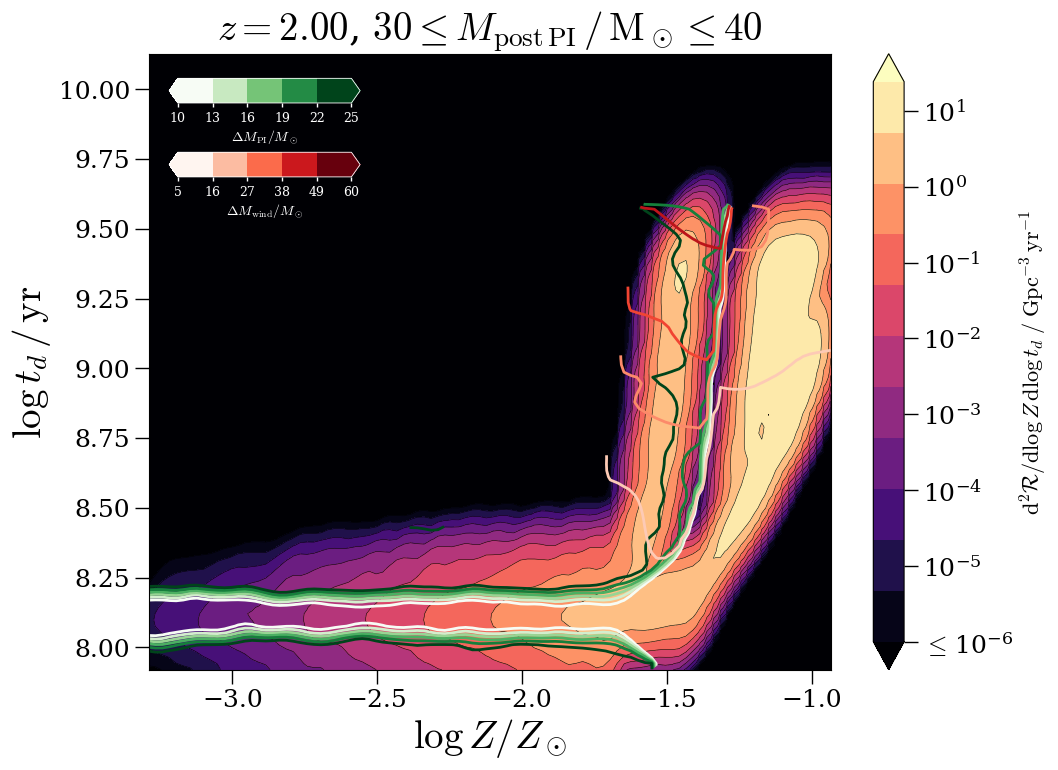

In [289]:
from scipy.ndimage import gaussian_filter
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from matplotlib.ticker import LogLocator, LogFormatterMathtext, FuncFormatter

def weighted_percentile(x, w, q):
    """Weighted percentile(s) q (0-100) of x; NaN values and non-positive weights are ignored."""
    ok = np.isfinite(x) & (w > 0)
    x, w = x[ok], w[ok]
    if x.size == 0:
        return np.full(np.shape(q), np.nan)
    order = np.argsort(x)
    x, w = x[order], w[order]
    cw = (np.cumsum(w) - 0.5 * w) / w.sum()
    return np.interp(np.asarray(q) / 100.0, cw, x)


def style_rate_colorbar(cbar, rate_floor, rate_ceil=None):
    """Log ticks, </>= labels at floor/ceil, and the rate axis label."""
    cbar.locator = LogLocator(base=10, numticks=8)
    base_fmt = LogFormatterMathtext()
    def _fmt(x, pos, _bf=base_fmt, _fl=rate_floor, _cl=rate_ceil):
        s = _bf(x, pos)
        if x > 0 and abs(np.log10(x) - np.log10(_fl)) < 0.05:
            return r'$\leq\,$' + s
        if _cl is not None and x > 0 and abs(np.log10(x) - np.log10(_cl)) < 0.05:
            return r'$\geq\,$' + s
        return s
    cbar.formatter = FuncFormatter(_fmt)
    cbar.update_ticks()
    cbar.set_label(r'$\mathrm{d}^2\mathcal{R}/\mathrm{d}\log Z\,\mathrm{d}\log t_d\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$', fontsize=16)


def plot_rate_2d_panel(ax, merger_df, rate_result, var, mass_slice, redshift,
                       n_bins=60, kde_bw=0.15, rate_floor=1e-6, rate_ceil=None,
                       n_levels=12, cmap='magma', linewidths=0.4, filled=True, xlim=None, ylim=None,
                       overlays=(), overlay_colorbars=True, overlay_lower_truncation=0.0, overlay_limit_percentiles=(1, 99), overlay_limits_nonzero_only=True,
                       title=False, colorbar=False):
    """Draw log-Z / log-t_d merger-rate contours on `ax` (filled=False -> line-only, coloured by cmap).
    overlays: sequence of dicts with keys var, smooth, n_levels (default 4), cmap, alpha, lw, vmin/vmax
    (default: rate-weighted overlay_limit_percentiles of the raw values (nonzero ones only if overlay_limits_nonzero_only), vmin floored to a multiple of n_levels, level spacing rounded up to a multiple of n_levels so ticks are round numbers), label; cells of the field with no data are NaN (lines end there)
    (entries with empty var are skipped). A field that is 0 everywhere gets the text 'No <label>' instead of a colorbar.
    overlay_lower_truncation (0-1): fraction of the low end of each overlay colormap that is cut off. Returns (contour set, rate colorbar or None, z_used)."""
    fig = ax.figure
    weights, z_used = rate_weights_at_redshift(rate_result, redshift)
    m_vals, m_mask = select_parameter(merger_df, var, drop_pisn=True)
    cut = m_mask & (m_vals >= mass_slice[0]) & (m_vals <= mass_slice[1])
    log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[cut])
    log_td = merger_df['log_t_d'].to_numpy()[cut]
    w = weights[cut]

    zb = np.linspace(xlim[0] if xlim else log_z.min(), xlim[1] if xlim else log_z.max(), n_bins + 1)
    tb = np.linspace(ylim[0] if ylim else log_td.min(), ylim[1] if ylim else log_td.max(), n_bins + 1)
    rate_2d, _, _ = differential_rate_2d(log_z, log_td, w, zb, tb, log_x=False, log_y=False,
                                         kde=True, bw_method=kde_bw)
    zc, tc = 0.5 * (zb[:-1] + zb[1:]), 0.5 * (tb[:-1] + tb[1:])

    rate_plot = np.where(rate_2d > 0, rate_2d, np.nan)
    vmax = rate_ceil if rate_ceil is not None else np.nanmax(rate_plot)
    n_lev = n_levels if n_levels is not None else max(int(np.round(2 * (np.log10(vmax) - np.log10(rate_floor)))) + 1, 3)
    levels = np.logspace(np.log10(rate_floor), np.log10(vmax), n_lev)
    norm = LogNorm(vmin=rate_floor, vmax=vmax)

    ax.set_facecolor(plt.get_cmap(cmap)(0.0))
    cf = None
    if filled:
        cf = ax.contourf(zc, tc, rate_plot.T, levels=levels, cmap=cmap, norm=norm, extend='both')
    if linewidths > 0:
        cl = ax.contour(zc, tc, rate_plot.T, levels=levels, norm=norm, linewidths=linewidths,
                        **(dict(colors='k') if filled else dict(cmap=cmap)))
        cf = cf if cf is not None else cl

    active = [o for o in overlays if o.get('var')]
    for k, o in enumerate(active):
        c_vals = np.nan_to_num(merger_df[o['var']].to_numpy()[cut].astype(float))
        num, _, _ = np.histogram2d(log_z, log_td, bins=[zb, tb], weights=w * c_vals)
        den, _, _ = np.histogram2d(log_z, log_td, bins=[zb, tb], weights=w)
        if o.get('smooth', 0) > 0:
            num = gaussian_filter(np.nan_to_num(num), sigma=o['smooth'])
            den = gaussian_filter(np.nan_to_num(den), sigma=o['smooth'])
        mean = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
        no_data = not np.any(np.nan_to_num(mean) != 0)
        n_lev_o = o.get('n_levels', 4)
        raw = merger_df[o['var']].to_numpy()[cut].astype(float)
        keep = raw != 0 if overlay_limits_nonzero_only else np.ones(raw.shape, bool)
        p_lo, p_hi = weighted_percentile(raw[keep], w[keep], overlay_limit_percentiles)
        vmin_o = o.get('vmin') if o.get('vmin') is not None else n_lev_o * np.floor(np.nan_to_num(p_lo) / n_lev_o)
        if o.get('vmax') is not None:
            vmax_o = o['vmax']
        else:
            step = n_lev_o * max(1, np.ceil((np.nan_to_num(p_hi) - vmin_o) / max(n_lev_o - 1, 1) / n_lev_o))
            vmax_o = vmin_o + step * max(n_lev_o - 1, 1)
        if vmax_o <= vmin_o:
            vmax_o = vmin_o + n_lev_o
        lev = np.linspace(vmin_o, vmax_o, n_lev_o)
        base_cmap = plt.get_cmap(o.get('cmap', 'Greens'))
        ocm = LinearSegmentedColormap.from_list('ov_trunc', base_cmap(np.linspace(overlay_lower_truncation, 1, 256)))
        if not no_data:
            ax.contour(zc, tc, mean.T, levels=lev, cmap=ocm, norm=Normalize(lev[0], lev[-1]),
                       alpha=o.get('alpha', 1), linewidths=o.get('lw', 1.5))
        if overlay_colorbars:
            cax = ax.inset_axes([0.03, 0.92 - 0.12 * k, 0.28, 0.04])
            if no_data:
                cax.axis('off')
                cax.text(0.5, 0.5, f"No {o.get('label') or param_label(o['var'])}", transform=cax.transAxes, color='white',
                         ha='center', va='center', fontsize=10)
            else:
                sm = ScalarMappable(norm=BoundaryNorm(lev, ncolors=ocm.N, clip=False), cmap=ocm)
                ocb = fig.colorbar(sm, cax=cax, orientation='horizontal', boundaries=lev, ticks=lev,
                                   extend='both', extendfrac=0.05)
                ocb.ax.tick_params(labelsize=9, colors='white', length=3)
                ocb.outline.set_edgecolor('white')
                ocb.outline.set_linewidth(0.6)
                ocb.set_label(o.get('label') or param_label(o['var']), fontsize=10, color='white', labelpad=2)

    ax.set_xlabel(r'$\log Z/Z_\odot$')
    ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
    if title:
        ax.set_title(rf'$z = {z_used:.2f}$, ${mass_slice[0]} \leq ${param_label(var)}$ \leq {mass_slice[1]}$')

    cbar = None
    if colorbar:
        cbar = fig.colorbar(cf, ax=ax)
        style_rate_colorbar(cbar, rate_floor, rate_ceil)
    return cf, cbar, z_used


# --- Example: same settings as the single-panel cell above, hardcoded ---
fig, ax = plt.subplots(figsize=(11, 8))
plot_rate_2d_panel(
    ax, merger_df, rate_result, var='m_post_pi', mass_slice=(30, 40), redshift=2,
    n_bins=100, kde_bw=0.15, rate_floor=1e-6, rate_ceil=None, n_levels=12,
    cmap='magma', linewidths=0.4, xlim=None, ylim=None,
    overlays=[
        dict(var='pi_delta_m', smooth=1.5, n_levels=6, cmap='Greens', alpha=1, lw=2,
             vmin=10, vmax=25, label=r'$\Delta M_{\rm PI}/M_\odot$'),
        dict(var='wind_delta_m', smooth=1.5, n_levels=6, cmap='Reds', alpha=1, lw=2,
             vmin=5, vmax=60, label=r'$\Delta M_{\rm wind}/M_\odot$'),
    ],
    title=True, colorbar=True,
)

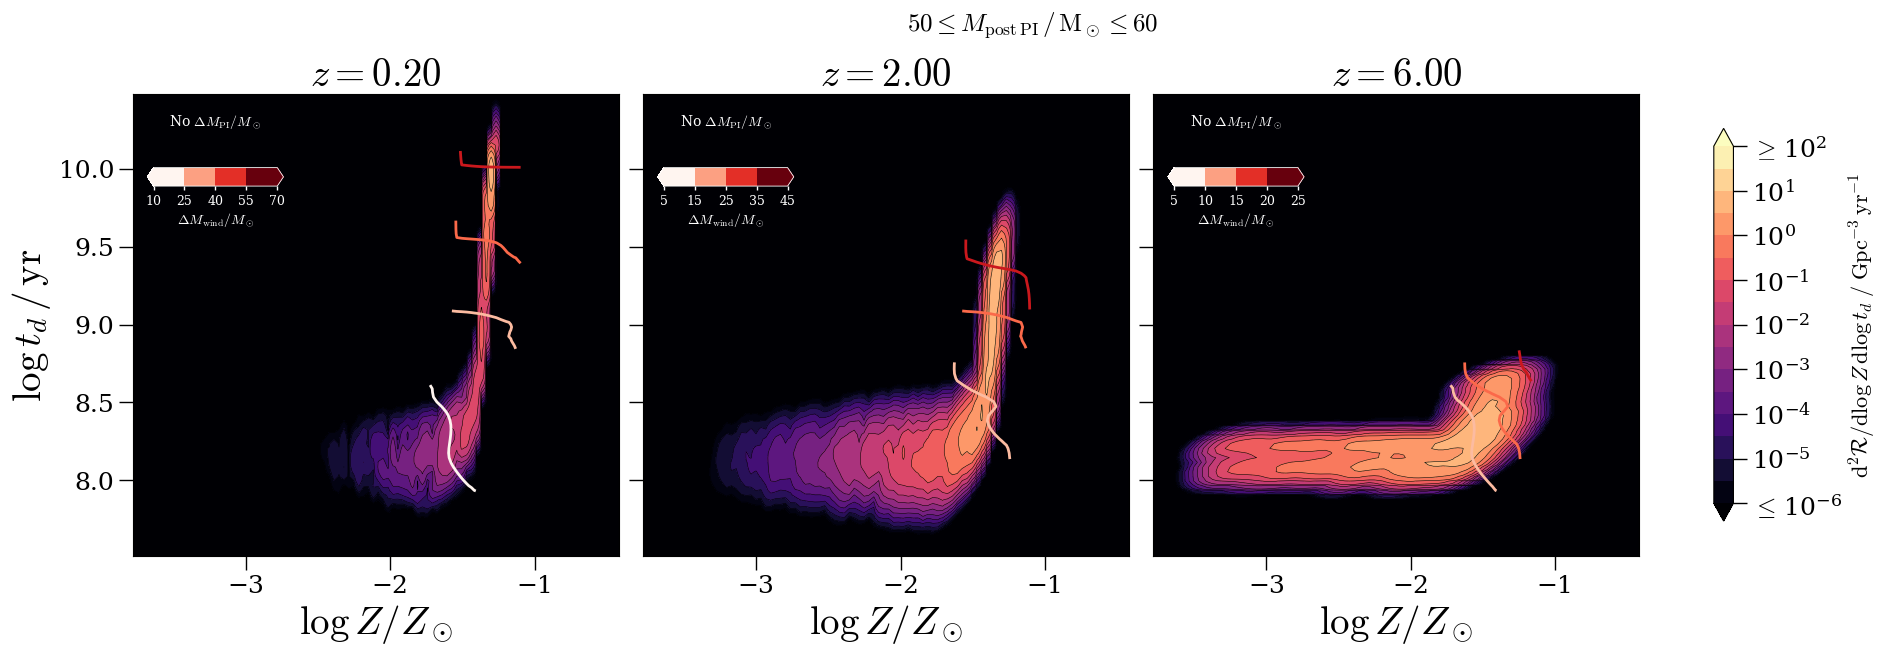

In [ ]:
# --- User settings ---
VAR = 'm_post_pi'               # population column to slice on
MASS_SLICE = (50, 60)            # mass window [Msun]
REDSHIFTS_3P = [0.2, 2.0, 6.0]  # one panel per redshift
N_BINS_2D = 100                   # KDE evaluation grid per axis
KDE_BW_2D = 0.2                 # 2-D KDE bandwidth (dex; both axes are log-spaced)

# contour settings
RATE_FLOOR = 1e-6                # minimum rate density shown [Gpc^-3 yr^-1 dex^-2]
N_LEVELS = None                    # number of contour levels (log-spaced between floor and max)
FILLED = True                    # filled contours (contourf) vs line-only (contour)
CONTOUR_CMAP = 'magma'           # colormap
CONTOUR_LINEWIDTHS = 0.4
XLIM = (-3.8, -0.4)                      # x-axis limits; None -> auto
YLIM = (7.5, 10.5)                      # y-axis limits; None -> auto
RATE_CEIL = 1e2                 # max rate density shown; None -> auto from data

# overlay variable contours, computed separately in each panel (var '' -> off).
# vmin/vmax None -> panel's rate-weighted OVERLAY_LIMIT_PERCENTILES of the raw values, vmin floored to a multiple of n_levels, level spacing rounded up to a multiple of n_levels.
OVERLAYS_3P = [
    dict(var='pi_delta_m', smooth=1.5, n_levels=5, cmap='Greens', alpha=1, lw=2,
         vmin=None, vmax=None, label=r'$\Delta M_{\rm PI}/M_\odot$'),
    dict(var='wind_delta_m', smooth=1.5, n_levels=5, cmap='Reds', alpha=1, lw=2,
         vmin=None, vmax=None, label=r'$\Delta M_{\rm wind}/M_\odot$'),
]
OVERLAY_LIMIT_PERCENTILES = (1, 99)   # rate-weighted percentiles that set the automatic overlay limits
OVERLAY_LIMITS_NONZERO_ONLY = True      # automatic limits ignore systems whose overlay value is exactly 0
OVERLAY_LOWER_TRUNCATION = 0.0   # 0-1: fraction of the low end of each overlay colormap to cut off

assert RATE_CEIL is not None, 'set RATE_CEIL so all panels share one colour scale'

# --- Three-panel figure: one plot_rate_2d_panel call per redshift ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.05)

for ax, _z in zip(axes, REDSHIFTS_3P):
    cf, _, z_used = plot_rate_2d_panel(
        ax, merger_df, rate_result, VAR, MASS_SLICE, _z,
        n_bins=N_BINS_2D, kde_bw=KDE_BW_2D, rate_floor=RATE_FLOOR, rate_ceil=RATE_CEIL,
        n_levels=N_LEVELS, cmap=CONTOUR_CMAP, linewidths=CONTOUR_LINEWIDTHS, filled=FILLED,
        xlim=XLIM, ylim=YLIM,
        overlays=OVERLAYS_3P, overlay_lower_truncation=OVERLAY_LOWER_TRUNCATION,
        overlay_limit_percentiles=OVERLAY_LIMIT_PERCENTILES, overlay_limits_nonzero_only=OVERLAY_LIMITS_NONZERO_ONLY,
    )
    ax.set_title(rf'$z = {z_used:.2f}$')
    if ax is not axes[0]:
        ax.set_ylabel('')

fig.suptitle(
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$',
    fontsize=18, y=1.02,
)   
cbar = fig.colorbar(cf, ax=axes.tolist(), shrink=0.85, pad=0.04)
style_rate_colorbar(cbar, RATE_FLOOR, RATE_CEIL)
savefig(fig, f'rate_2d_logz_logtd_{VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}_3panel')

separate bin density between rates and overlays to smooth delta m contours


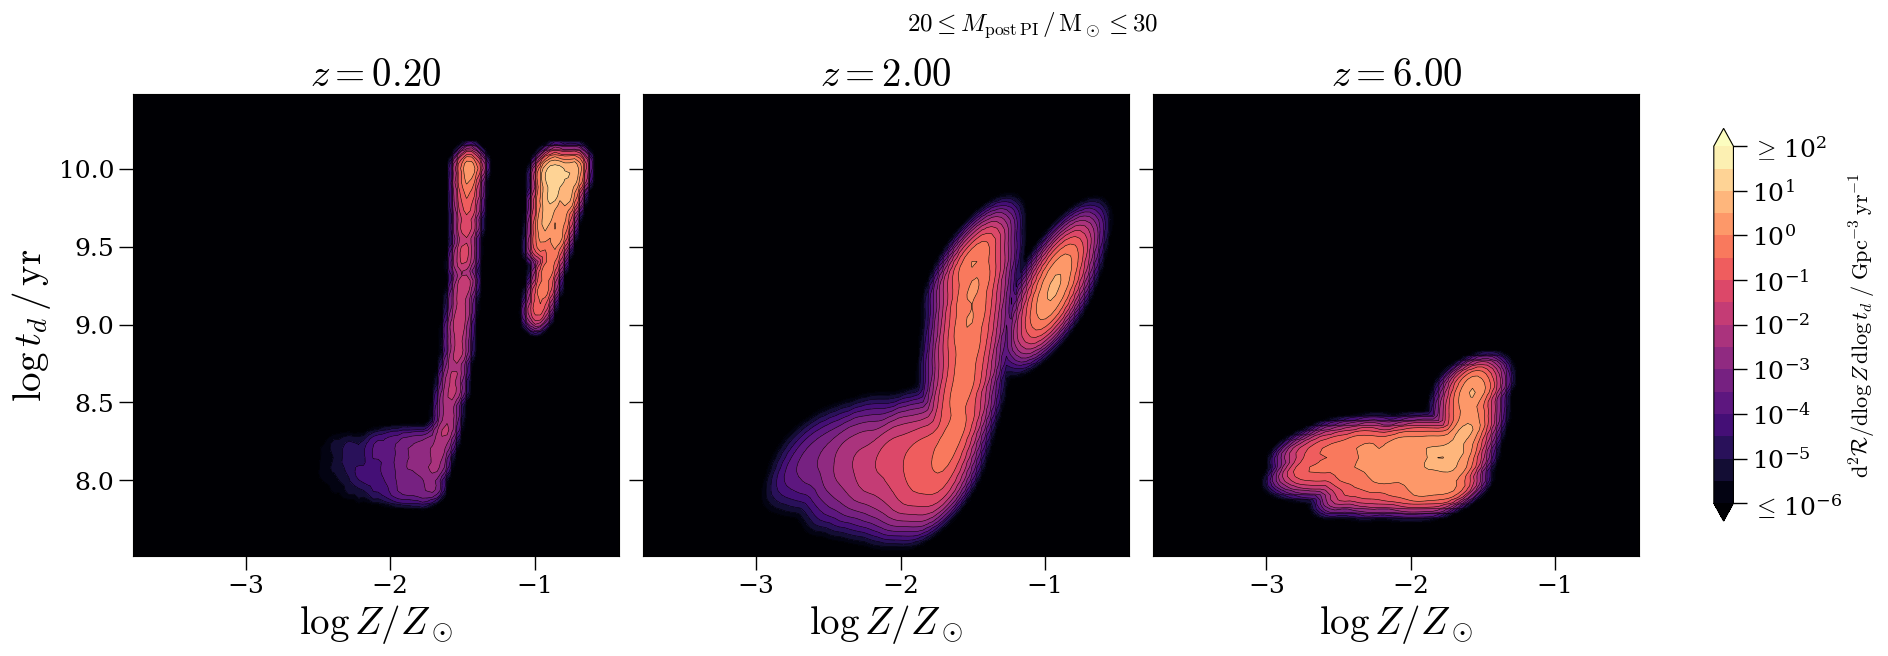

In [266]:
# --- User settings ---
VAR = 'm_post_pi'               # population column to slice on
MASS_SLICE = (20, 30)            # mass window [Msun]
REDSHIFTS_3P = [0.2, 2.0, 6.0]  # one panel per redshift
N_BINS_2D = 100                   # KDE evaluation grid per axis
KDE_BW_2D = 0.2                 # 2-D KDE bandwidth (dex; both axes are log-spaced)

# contour settings
RATE_FLOOR = 1e-6                # minimum rate density shown [Gpc^-3 yr^-1 dex^-2]
N_LEVELS = None                    # number of contour levels (log-spaced between floor and max)
FILLED = True                    # filled contours (contourf) vs line-only (contour)
CONTOUR_CMAP = 'magma'           # colormap
CONTOUR_LINEWIDTHS = 0.4
XLIM = (-3.8, -0.4)                      # x-axis limits; None -> auto
YLIM = (7.5, 10.5)                      # y-axis limits; None -> auto
RATE_CEIL = 1e2                 # max rate density shown; None -> auto from data

# --- Mass slice (computed once, shared by all panels) ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]

log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

# --- Compute 2-D KDE rate per panel ---
rate_panels = []
z_used_panels = []
for _z in REDSHIFTS_3P:
    w_z, z_used = rate_weights_at_redshift(rate_result, _z)
    z_used_panels.append(z_used)
    w_cut = w_z[mass_cut]
    rate_2d, _, _ = differential_rate_2d(
        log_z, log_td, w_cut,
        log_z_bins, log_td_bins,
        log_x=False, log_y=False,
        kde=True, bw_method=KDE_BW_2D,
    )
    rate_panels.append(np.where(rate_2d > 0, rate_2d, np.nan))

# --- Shared color scale ---
_all_rates = np.concatenate([r.ravel() for r in rate_panels])
_vmax = RATE_CEIL if RATE_CEIL is not None else np.nanmax(_all_rates)
_n_decades = np.log10(_vmax) - np.log10(RATE_FLOOR)
_n_levels = N_LEVELS if N_LEVELS is not None else max(int(np.round(2 * _n_decades)) + 1, 3)
levels = np.logspace(np.log10(RATE_FLOOR), np.log10(_vmax), _n_levels)
_norm = LogNorm(vmin=RATE_FLOOR, vmax=_vmax)

# --- Three-panel figure ---
from matplotlib.ticker import LogLocator, LogFormatterMathtext

fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True, sharex=True,
)
fig.subplots_adjust(wspace=0.05)

for ax, rate_plot, z_used in zip(axes, rate_panels, z_used_panels):
    if FILLED:
        cf = ax.contourf(log_z_c, log_td_c, rate_plot.T, levels=levels,
                          cmap=CONTOUR_CMAP, norm=_norm, extend='both')
    if CONTOUR_LINEWIDTHS > 0:
        ax.contour(log_z_c, log_td_c, rate_plot.T, levels=levels,
                   colors='k' if FILLED else None,
                   cmap=None if FILLED else CONTOUR_CMAP,
                   norm=_norm, linewidths=CONTOUR_LINEWIDTHS)
    ax.set_facecolor(plt.get_cmap(CONTOUR_CMAP)(0.0))
    ax.set_xlabel(r'$\log Z/Z_\odot$')
    ax.set_title(rf'$z = {z_used:.2f}$')
        
axes[0].set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')

fig.suptitle(
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$',
    fontsize=18, y=1.02,
)
cbar = fig.colorbar(cf, ax=axes.tolist(), shrink=0.85, pad=0.04)
cbar.locator = LogLocator(base=10, numticks=8)
_base_fmt = LogFormatterMathtext()
def _leq_fmt(x, pos, _bf=_base_fmt, _fl=RATE_FLOOR, _cl=RATE_CEIL):
    s = _bf(x, pos)
    if (x > 0 and abs(np.log10(x) - np.log10(_fl)) < 0.05):
        return (r'$\leq\,$' + s)
    elif (x > 0 and abs(np.log10(x) - np.log10(_cl)) < 0.05):
        return (r'$\geq\,$' + s)
    else:
        return s
cbar.formatter = FuncFormatter(_leq_fmt)
cbar.update_ticks()
cbar.set_label(
    r'$\mathrm{d}^2\mathcal{R}'
    r'/\mathrm{d}\log Z\,\mathrm{d}\log t_d'
    r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
    fontsize=16,
)
savefig(fig, f'rate_2d_logz_logtd_{VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}_3panel')

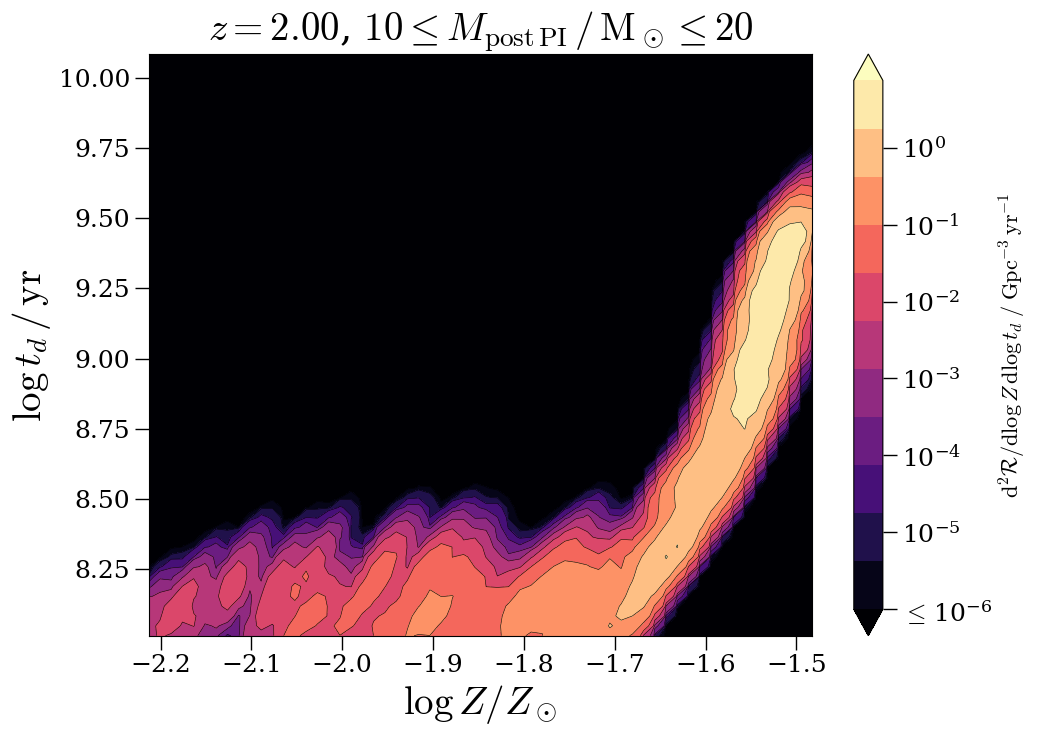

In [ ]:
# --- User settings ---
VAR = 'm_post_pi'               # population column to slice on
MASS_SLICE = (10, 20)            # mass window [Msun]
REDSHIFT_2D = 2                # observation redshift
N_BINS_2D = 60                   # KDE evaluation grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex; both axes are log-spaced)

# contour settings
RATE_FLOOR = 1e-6                # minimum rate density shown [Gpc^-3 yr^-1 dex^-2]
N_LEVELS = 12                   # contour levels; None -> 2 levels per decade
FILLED = True                    # filled contours (contourf) vs line-only (contour)
CONTOUR_CMAP = 'magma'           # colormap
CONTOUR_LINEWIDTHS = 0.4
XLIM = None                      # x-axis limits; None -> auto
YLIM = None                      # y-axis limits; None -> auto
RATE_CEIL = None                 # max rate density shown; None -> auto from data

# --- Per-system rate weights at the chosen redshift ---
weights_2d, z_used_2d = rate_weights_at_redshift(rate_result, REDSHIFT_2D)

# --- Mass slice ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
w_cut = weights_2d[mass_cut]

# --- Bin edges and 2-D KDE ---
log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)

rate_2d, _, _ = differential_rate_2d(
    log_z, log_td, w_cut,
    log_z_bins, log_td_bins,
    log_x=False, log_y=False,
    kde=True, bw_method=KDE_BW_2D,
)

# --- Contour plot ---
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

rate_plot = np.where(rate_2d > 0, rate_2d, np.nan)
vmax = RATE_CEIL if RATE_CEIL is not None else np.nanmax(rate_plot)
_n_decades = np.log10(vmax) - np.log10(RATE_FLOOR)
_n_levels = N_LEVELS if N_LEVELS is not None else max(int(np.round(2 * _n_decades)) + 1, 3)
levels = np.logspace(np.log10(RATE_FLOOR), np.log10(vmax), _n_levels)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor(plt.get_cmap(CONTOUR_CMAP)(0.0))
if FILLED:
    cf = ax.contourf(log_z_c, log_td_c, rate_plot.T, levels=levels,
                      cmap=CONTOUR_CMAP, norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
                      extend='both')
if CONTOUR_LINEWIDTHS > 0:
    ax.contour(log_z_c, log_td_c, rate_plot.T, levels=levels,
               colors='k' if FILLED else None,
               cmap=None if FILLED else CONTOUR_CMAP,
               norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
               linewidths=CONTOUR_LINEWIDTHS)

ax.set_xlabel(r'$\log Z/Z_\odot$')
ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
ax.set_title(
    rf'$z = {z_used_2d:.2f}$, '
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$'
)

from matplotlib.ticker import LogLocator, LogFormatterMathtext, FuncFormatter
cbar = fig.colorbar(cf if FILLED else ax.collections[0], ax=ax)
cbar.locator = LogLocator(base=10, numticks=8)
_base_fmt = LogFormatterMathtext()
def _leq_fmt(x, pos, _bf=_base_fmt, _fl=RATE_FLOOR):
    s = _bf(x, pos)
    return (r'$\leq\,$' + s) if (x > 0 and abs(np.log10(x) - np.log10(_fl)) < 0.05) else s
cbar.formatter = FuncFormatter(_leq_fmt)
cbar.update_ticks()
cbar.set_label(
    r'$\mathrm{d}^2\mathcal{R}'
    r'/\mathrm{d}\log Z\,\mathrm{d}\log t_d'
    r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
    fontsize=16,
)
fig.tight_layout()
savefig(fig, f'rate_2d_logz_logtd_{VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}')

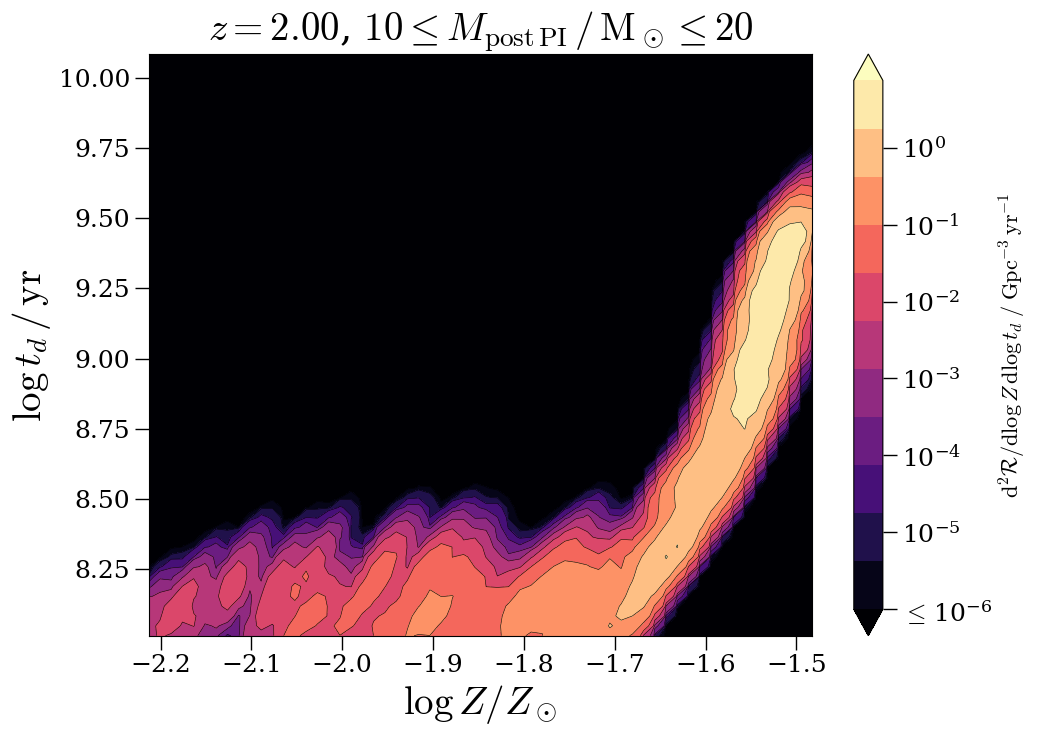

In [241]:
# --- User settings ---
VAR = 'm_post_pi'               # population column to slice on
MASS_SLICE = (10, 20)            # mass window [Msun]
REDSHIFT_2D = 2                # observation redshift
N_BINS_2D = 60                   # KDE evaluation grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex; both axes are log-spaced)

# contour settings
RATE_FLOOR = 1e-6                # minimum rate density shown [Gpc^-3 yr^-1 dex^-2]
N_LEVELS = 12                   # contour levels; None -> 2 levels per decade
FILLED = True                    # filled contours (contourf) vs line-only (contour)
CONTOUR_CMAP = 'magma'           # colormap
CONTOUR_LINEWIDTHS = 0.4
XLIM = None                      # x-axis limits; None -> auto
YLIM = None                      # y-axis limits; None -> auto
RATE_CEIL = None                 # max rate density shown; None -> auto from data

# --- Per-system rate weights at the chosen redshift ---
weights_2d, z_used_2d = rate_weights_at_redshift(rate_result, REDSHIFT_2D)

# --- Mass slice ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
w_cut = weights_2d[mass_cut]

# --- Bin edges and 2-D KDE ---
log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)

rate_2d, _, _ = differential_rate_2d(
    log_z, log_td, w_cut,
    log_z_bins, log_td_bins,
    log_x=False, log_y=False,
    kde=True, bw_method=KDE_BW_2D,
)

# --- Contour plot ---
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

rate_plot = np.where(rate_2d > 0, rate_2d, np.nan)
vmax = RATE_CEIL if RATE_CEIL is not None else np.nanmax(rate_plot)
_n_decades = np.log10(vmax) - np.log10(RATE_FLOOR)
_n_levels = N_LEVELS if N_LEVELS is not None else max(int(np.round(2 * _n_decades)) + 1, 3)
levels = np.logspace(np.log10(RATE_FLOOR), np.log10(vmax), _n_levels)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor(plt.get_cmap(CONTOUR_CMAP)(0.0))
if FILLED:
    cf = ax.contourf(log_z_c, log_td_c, rate_plot.T, levels=levels,
                      cmap=CONTOUR_CMAP, norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
                      extend='both')
if CONTOUR_LINEWIDTHS > 0:
    ax.contour(log_z_c, log_td_c, rate_plot.T, levels=levels,
               colors='k' if FILLED else None,
               cmap=None if FILLED else CONTOUR_CMAP,
               norm=LogNorm(vmin=RATE_FLOOR, vmax=vmax),
               linewidths=CONTOUR_LINEWIDTHS)

ax.set_xlabel(r'$\log Z/Z_\odot$')
ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
ax.set_title(
    rf'$z = {z_used_2d:.2f}$, '
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$'
)

from matplotlib.ticker import LogLocator, LogFormatterMathtext, FuncFormatter
cbar = fig.colorbar(cf if FILLED else ax.collections[0], ax=ax)
cbar.locator = LogLocator(base=10, numticks=8)
_base_fmt = LogFormatterMathtext()
def _leq_fmt(x, pos, _bf=_base_fmt, _fl=RATE_FLOOR):
    s = _bf(x, pos)
    return (r'$\leq\,$' + s) if (x > 0 and abs(np.log10(x) - np.log10(_fl)) < 0.05) else s
cbar.formatter = FuncFormatter(_leq_fmt)
cbar.update_ticks()
cbar.set_label(
    r'$\mathrm{d}^2\mathcal{R}'
    r'/\mathrm{d}\log Z\,\mathrm{d}\log t_d'
    r'\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
    fontsize=16,
)
fig.tight_layout()
savefig(fig, f'rate_2d_logz_logtd_{VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}')

In [116]:
merger_df['wind_delta_m'] = np.abs(merger_df.m_f - merger_df.m_zams)
merger_df['pi_delta_m'] = np.abs(merger_df.m_post_pi - merger_df.m_f)
merger_df['total_delta_m'] = np.abs(merger_df.m_post_pi - merger_df.m_zams)

In [ ]:
# --- User settings ---
VAR = 'm_f'               # population column to slice on
MASS_SLICE = (30, 40)            # mass window [Msun]
REDSHIFT_2D = 0.2                # observation redshift
N_BINS_2D = 60                   # grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex)

# color-by-variable settings
COLOR_VAR = 'wind_delta_m'       # column to color by (rate-weighted mean per bin)
COLOR_CMAP = 'magma'             # colormap
COLOR_LABEL = None               # axis label override; None -> use param_label(COLOR_VAR)
COLOR_VMIN = 0                # colorbar min; None -> auto
COLOR_VMAX = 50                # colorbar max; None -> auto
COLOR_N_LEVELS = 20              # number of contour levels
COLOR_LOG = False                # log-scale color axis
SMOOTH_SIGMA = 1.0               # Gaussian smoothing in bin units (0 = none)
COLOR_LINEWIDTHS = 0.3           # contour edge line width (0 = no edges)
XLIM = None                      # x-axis limits; None -> auto
YLIM = None                      # y-axis limits; None -> auto
WEIGHT_MEAN_BY_RATE = False       # True: rate-weighted mean; False: plain mean

# --- Per-system rate weights at the chosen redshift ---
weights_2d, z_used_2d = rate_weights_at_redshift(rate_result, REDSHIFT_2D)

# --- Mass slice ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
w_cut = weights_2d[mass_cut]

# --- Bin edges ---
log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

# --- Rate-weighted mean of COLOR_VAR in each 2-D bin ---
from scipy.ndimage import gaussian_filter

c_vals = merger_df[COLOR_VAR].to_numpy()[mass_cut]
_w = w_cut if WEIGHT_MEAN_BY_RATE else np.ones_like(w_cut)
num, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=_w * c_vals)
den, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=_w)

if SMOOTH_SIGMA > 0:
    num = gaussian_filter(np.nan_to_num(num), sigma=SMOOTH_SIGMA)
    den = gaussian_filter(np.nan_to_num(den), sigma=SMOOTH_SIGMA)

mean_c = np.where(den > 0, num / den, np.nan)

# --- Contour levels and norm ---
_vmin = COLOR_VMIN if COLOR_VMIN is not None else np.nanmin(mean_c)
_vmax = COLOR_VMAX if COLOR_VMAX is not None else np.nanmax(mean_c)

if COLOR_LOG:
    _levels = np.logspace(np.log10(_vmin), np.log10(_vmax), COLOR_N_LEVELS)
    _norm = LogNorm(vmin=_vmin, vmax=_vmax)
else:
    _levels = np.linspace(_vmin, _vmax, COLOR_N_LEVELS)
    _norm = Normalize(vmin=_vmin, vmax=_vmax)

# --- Plot ---
clabel = COLOR_LABEL or param_label(COLOR_VAR)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor(plt.get_cmap(COLOR_CMAP)(0.0))
cf = ax.contourf(log_z_c, log_td_c, mean_c.T, levels=_levels,
                  cmap=COLOR_CMAP, norm=_norm, extend='both')
if COLOR_LINEWIDTHS > 0:
    ax.contour(log_z_c, log_td_c, mean_c.T, levels=_levels,
               colors='k', linewidths=COLOR_LINEWIDTHS)

ax.set_xlabel(r'$\log Z/Z_\odot$')
ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
ax.set_title(
    rf'$z = {z_used_2d:.2f}$, '
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$'
)
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(clabel, fontsize=16)
from matplotlib.ticker import FuncFormatter as _FF
_orig_fmt = cbar.formatter
def _leq_color_fmt(x, pos, _of=_orig_fmt, _fl=_vmin):
    s = _of(x, pos) if callable(_of) else f'{x:g}'
    return (r'$\leq\,$' + s) if abs(x - _fl) < abs(_vmax - _fl) * 0.01 else s
cbar.formatter = _FF(_leq_color_fmt)
cbar.update_ticks()
savefig(fig, f'rate_2d_logz_logtd_color_{COLOR_VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}')

In [ ]:
# --- User settings ---
VAR = 'm_f'                      # population column to slice on
MASS_SLICE = (30, 40)            # mass window [Msun]
REDSHIFTS_3P = [0.2, 2.0, 6.0]  # one panel per redshift
N_BINS_2D = 60                   # grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex)

# color-by-variable settings
COLOR_VAR = 'wind_delta_m'       # column to color by (mean per bin)
COLOR_CMAP = 'magma'             # colormap
COLOR_LABEL = None               # axis label override; None -> use param_label(COLOR_VAR)
COLOR_VMIN = 0                   # colorbar min; None -> auto (shared across panels)
COLOR_VMAX = 50                  # colorbar max; None -> auto (shared across panels)
COLOR_N_LEVELS = 20              # number of contour levels
COLOR_LOG = False                # log-scale color axis
SMOOTH_SIGMA = 1.0               # Gaussian smoothing in bin units (0 = none)
COLOR_LINEWIDTHS = 0.3           # contour edge line width (0 = no edges)
XLIM = None                      # x-axis limits; None -> auto
YLIM = None                      # y-axis limits; None -> auto
WEIGHT_MEAN_BY_RATE = False      # True: rate-weighted mean; False: plain mean

# --- Mass slice (computed once, shared by all panels) ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
c_vals = merger_df[COLOR_VAR].to_numpy()[mass_cut]

log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

from scipy.ndimage import gaussian_filter

# --- Compute mean_c per panel ---
mean_c_panels = []
z_used_panels = []
for _z in REDSHIFTS_3P:
    w_z, z_used = rate_weights_at_redshift(rate_result, _z)
    z_used_panels.append(z_used)
    w_cut = w_z[mass_cut]
    _w = w_cut if WEIGHT_MEAN_BY_RATE else np.ones_like(w_cut)
    num, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=_w * c_vals)
    den, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=_w)
    if SMOOTH_SIGMA > 0:
        num = gaussian_filter(np.nan_to_num(num), sigma=SMOOTH_SIGMA)
        den = gaussian_filter(np.nan_to_num(den), sigma=SMOOTH_SIGMA)
    mean_c_panels.append(np.where(den > 0, num / den, np.nan))

# --- Shared color scale ---
if COLOR_VMIN is not None and COLOR_VMAX is not None:
    _vmin, _vmax = COLOR_VMIN, COLOR_VMAX
else:
    _all = np.concatenate([m.ravel() for m in mean_c_panels])
    _vmin = COLOR_VMIN if COLOR_VMIN is not None else np.nanmin(_all)
    _vmax = COLOR_VMAX if COLOR_VMAX is not None else np.nanmax(_all)

if COLOR_LOG:
    _levels = np.logspace(np.log10(_vmin), np.log10(_vmax), COLOR_N_LEVELS)
    _norm = LogNorm(vmin=_vmin, vmax=_vmax)
else:
    _levels = np.linspace(_vmin, _vmax, COLOR_N_LEVELS)
    _norm = Normalize(vmin=_vmin, vmax=_vmax)

clabel = COLOR_LABEL or param_label(COLOR_VAR)

# --- Three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True, sharex=True,
)

for ax, mean_c, z_used in zip(axes, mean_c_panels, z_used_panels):
    cf = ax.contourf(log_z_c, log_td_c, mean_c.T, levels=_levels,
                      cmap=COLOR_CMAP, norm=_norm, extend='both')
    if COLOR_LINEWIDTHS > 0:
        ax.contour(log_z_c, log_td_c, mean_c.T, levels=_levels,
                   colors='k', linewidths=COLOR_LINEWIDTHS)
    ax.set_facecolor(plt.get_cmap(COLOR_CMAP)(0.0))
    ax.set_xlabel(r'$\log Z/Z_\odot$')
    ax.set_title(rf'$z = {z_used:.2f}$')
        
axes[0].set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')

fig.suptitle(
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$',
    fontsize=18, y=1.02,
)
cbar = fig.colorbar(cf, ax=axes.tolist(), shrink=0.85, pad=0.04)
cbar.set_label(clabel, fontsize=16)
from matplotlib.ticker import FuncFormatter as _FF
_orig_fmt = cbar.formatter
def _leq_color_fmt(x, pos, _of=_orig_fmt, _fl=_vmin):
    s = _of(x, pos) if callable(_of) else f'{x:g}'
    return (r'$\leq\,$' + s) if abs(x - _fl) < abs(_vmax - _fl) * 0.01 else s
cbar.formatter = _FF(_leq_color_fmt)
cbar.update_ticks()
savefig(fig, f'rate_2d_logz_logtd_color_{COLOR_VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}_3panel')

In [ ]:
# --- User settings ---
VAR = 'm_f'               # population column to slice on
MASS_SLICE = (30, 40)            # mass window [Msun]
REDSHIFT_2D = 2                # observation redshift
N_BINS_2D = 60                   # grid per axis
KDE_BW_2D = 0.15                 # 2-D KDE bandwidth (dex)

# color-by-variable settings
COLOR_VAR = 'wind_delta_m'       # column to color by (rate-weighted mean per bin)
COLOR_CMAP = 'magma'             # colormap
COLOR_LABEL = None               # axis label override; None -> use param_label(COLOR_VAR)
COLOR_VMIN = 0               # colorbar min; None -> auto
COLOR_VMAX = 50                # colorbar max; None -> auto
COLOR_N_LEVELS = 20              # number of contour levels
COLOR_LOG = False                # log-scale color axis
SMOOTH_SIGMA = 1.0               # Gaussian smoothing in bin units (0 = none)
COLOR_LINEWIDTHS = 0.3           # contour edge line width (0 = no edges)
XLIM = None                      # x-axis limits; None -> auto
YLIM = None                      # y-axis limits; None -> auto
WEIGHT_MEAN_BY_RATE = True       # True: rate-weighted mean; False: plain mean

# --- Per-system rate weights at the chosen redshift ---
weights_2d, z_used_2d = rate_weights_at_redshift(rate_result, REDSHIFT_2D)

# --- Mass slice ---
m_vals, m_mask = select_parameter(merger_df, VAR, drop_pisn=True)
mass_cut = m_mask & (m_vals >= MASS_SLICE[0]) & (m_vals <= MASS_SLICE[1])

log_z = np.log10(merger_df['z_div_zsun'].to_numpy()[mass_cut])
log_td = merger_df['log_t_d'].to_numpy()[mass_cut]
w_cut = weights_2d[mass_cut]

# --- Bin edges ---
log_z_bins = np.linspace(XLIM[0] if XLIM else log_z.min(), XLIM[1] if XLIM else log_z.max(), N_BINS_2D + 1)
log_td_bins = np.linspace(YLIM[0] if YLIM else log_td.min(), YLIM[1] if YLIM else log_td.max(), N_BINS_2D + 1)
log_z_c = 0.5 * (log_z_bins[:-1] + log_z_bins[1:])
log_td_c = 0.5 * (log_td_bins[:-1] + log_td_bins[1:])

# --- Rate-weighted mean of COLOR_VAR in each 2-D bin ---
from scipy.ndimage import gaussian_filter

c_vals = merger_df[COLOR_VAR].to_numpy()[mass_cut]
_w = w_cut if WEIGHT_MEAN_BY_RATE else np.ones_like(w_cut)
num, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=_w * c_vals)
den, _, _ = np.histogram2d(log_z, log_td, bins=[log_z_bins, log_td_bins], weights=_w)

if SMOOTH_SIGMA > 0:
    num = gaussian_filter(np.nan_to_num(num), sigma=SMOOTH_SIGMA)
    den = gaussian_filter(np.nan_to_num(den), sigma=SMOOTH_SIGMA)

mean_c = np.where(den > 0, num / den, np.nan)

# --- Contour levels and norm ---
_vmin = COLOR_VMIN if COLOR_VMIN is not None else np.nanmin(mean_c)
_vmax = COLOR_VMAX if COLOR_VMAX is not None else np.nanmax(mean_c)

if COLOR_LOG:
    _levels = np.logspace(np.log10(_vmin), np.log10(_vmax), COLOR_N_LEVELS)
    _norm = LogNorm(vmin=_vmin, vmax=_vmax)
else:
    _levels = np.linspace(_vmin, _vmax, COLOR_N_LEVELS)
    _norm = Normalize(vmin=_vmin, vmax=_vmax)

# --- Plot ---
clabel = COLOR_LABEL or param_label(COLOR_VAR)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor(plt.get_cmap(COLOR_CMAP)(0.0))
cf = ax.contourf(log_z_c, log_td_c, mean_c.T, levels=_levels,
                  cmap=COLOR_CMAP, norm=_norm, extend='both')
if COLOR_LINEWIDTHS > 0:
    ax.contour(log_z_c, log_td_c, mean_c.T, levels=_levels,
               colors='k', linewidths=COLOR_LINEWIDTHS)

ax.set_xlabel(r'$\log Z/Z_\odot$')
ax.set_ylabel(r'$\log t_d\,/\,\mathrm{yr}$')
ax.set_title(
    rf'$z = {z_used_2d:.2f}$, '
    rf'${MASS_SLICE[0]} \leq ${param_label(VAR)}$ \leq {MASS_SLICE[1]}$'
)
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(clabel, fontsize=16)
fig.tight_layout()
from matplotlib.ticker import FuncFormatter as _FF
_orig_fmt = cbar.formatter
def _leq_color_fmt(x, pos, _of=_orig_fmt, _fl=_vmin):
    s = _of(x, pos) if callable(_of) else f'{x:g}'
    return (r'$\leq\,$' + s) if abs(x - _fl) < abs(_vmax - _fl) * 0.01 else s
cbar.formatter = _FF(_leq_color_fmt)
cbar.update_ticks()
savefig(fig, f'rate_2d_logz_logtd_color_{COLOR_VAR}_{MASS_SLICE[0]}_{MASS_SLICE[1]}')

### 6.4 Pairing function study

This is an experiment to check the emerging m1 and m2 marginals, the mixed m1 marginal+lower power law, and the joint 2d m1,m2 distribution, if we treat the CHE mass model as the arbitrary mass outcome model for CHE. CHE generally goes through

1. An initial contact binary phase that shapes the mass ratio distribution $g(q)$.
2. A detached wind-dominated phase that sets the final mass distribution for isolated evolution.

But only m2 can sample the whole CHE range, because CHE has a minimum mass m_CHE, and thus m1 >= m2 >= m_CHE.

We can perform the following experiment

1. Fix m2 to the CHE mass model.
2. For each m2 draw n_q q from g(q) and define m1
3. What m1 emerges? Get m1 distribution and visualize against m2
4. Generate a new m1 model and mix it with the power law from LVK

In [37]:
PAIRING_Q_SCHEDULE = {
    'm_low': 20.0,
    'm_high': 40.0,
    'mu_low': 1.0,
    'sigma_low': 0.05,
    'mu_high': 0.8,
    'sigma_high': 0.1,
}


def mass_ratio_gaussian_params(m, **schedule):
    """Return the centre and width of the Gaussian pairing function g(q | m).

    The Gaussian is narrow and centred on equal masses at and below ``m_low``,
    broad and centred on ``mu_high`` at and above ``m_high``, and ramps linearly
    between the two.

    Parameters
    ----------
    m : array_like
        Secondary masses in solar masses.
    **schedule
        Any of ``m_low``, ``m_high``, ``mu_low``, ``sigma_low``, ``mu_high`` and
        ``sigma_high``, overriding ``PAIRING_Q_SCHEDULE``.

    Returns
    -------
    mu, sigma : numpy.ndarray
        Centre and standard deviation of g(q | m) at each mass.
    """
    unknown = set(schedule) - set(PAIRING_Q_SCHEDULE)
    if unknown:
        raise TypeError(f'unknown pairing-schedule parameters: {sorted(unknown)}')
    s = {**PAIRING_Q_SCHEDULE, **schedule}
    if s['m_high'] <= s['m_low']:
        raise ValueError('require m_low < m_high')

    m = np.atleast_1d(np.asarray(m, dtype=float))
    ramp = np.clip((m - s['m_low']) / (s['m_high'] - s['m_low']), 0.0, 1.0)
    mu = s['mu_low'] + ramp * (s['mu_high'] - s['mu_low'])
    sigma = s['sigma_low'] + ramp * (s['sigma_high'] - s['sigma_low'])
    return mu, sigma


PAIRING_KINDS = ('uniform', 'power_law', 'correlated_gaussian')


def sample_mass_ratios(mass, kind='uniform', q_min=0.5, q_max=1.0, beta_q=0.0,
                       rng=None, **schedule):
    """Draw one mass ratio per mass from the chosen pairing function g(q).

    Parameters
    ----------
    mass : array_like
        Secondary masses; one ratio is drawn per entry. Only
        ``'correlated_gaussian'`` depends on the mass itself -- the other two use
        it just to set the number of draws.
    kind : {'uniform', 'power_law', 'correlated_gaussian'}
        Pairing function. ``'uniform'`` is flat on ``[q_min, q_max]``,
        ``'power_law'`` is proportional to ``q**beta_q`` there, and
        ``'correlated_gaussian'`` is a Gaussian whose centre and width follow the
        secondary mass through :func:`mass_ratio_gaussian_params`, truncated to
        the same bounds.
    q_min, q_max : float
        Support of g(q). ``q_max`` is 1 by the definition ``q = m2 / m1 <= 1``;
        for the correlated Gaussian ``q_min`` should sit several sigma below the
        lowest centre so the distribution is not clipped.
    beta_q : float
        Power-law index, used only when ``kind='power_law'``.
    rng : numpy.random.Generator, optional
        Generator to draw from; a fresh default generator is used when omitted.
    **schedule
        Passed to :func:`mass_ratio_gaussian_params`, used only when
        ``kind='correlated_gaussian'``.

    Returns
    -------
    numpy.ndarray
        The sampled mass ratios, one per entry of ``mass``.
    """
    if kind not in PAIRING_KINDS:
        raise ValueError(f'kind must be one of {PAIRING_KINDS}')
    if not 0.0 < q_min < q_max <= 1.0:
        raise ValueError('require 0 < q_min < q_max <= 1')
    if schedule and kind != 'correlated_gaussian':
        raise TypeError(
            f"schedule parameters {sorted(schedule)} only apply to "
            f"kind='correlated_gaussian', not kind={kind!r}"
        )

    rng = np.random.default_rng() if rng is None else rng
    mass = np.atleast_1d(np.asarray(mass, dtype=float))
    u = rng.random(mass.shape)

    if kind == 'uniform':
        return q_min + u * (q_max - q_min)

    if kind == 'power_law':
        if np.isclose(beta_q, -1.0):
            return q_min * (q_max / q_min) ** u
        power = beta_q + 1.0
        return (q_min ** power + u * (q_max ** power - q_min ** power)) ** (1.0 / power)

    # correlated_gaussian: inverse-CDF draw from the mass-dependent truncated Gaussian
    mu, sigma = mass_ratio_gaussian_params(mass, **schedule)
    low = norm.cdf((q_min - mu) / sigma)
    high = norm.cdf((q_max - mu) / sigma)
    return np.clip(mu + sigma * norm.ppf(low + u * (high - low)), q_min, q_max)

def pair_che_masses(
    che_model,
    n_m2=400,
    n_q=100,
    m2_min=None,
    m2_max=None,
    m1_max=None,
    steepen=0.0,
    peak_mass=None,
    kind='uniform',
    q_min=0.5,
    q_max=1.0,
    beta_q=0.0,
    schedule=None,
    seed=0,
):
    """Treat the smoothed CHE rate as the secondary mass model and pair it with g(q).

    The secondary is drawn from ``che_model`` itself, so whatever the model says --
    including its low-mass clamp -- is what the experiment sees. Masses are taken on
    a midpoint grid and weighted by dR/dm2, which reproduces the model curve exactly
    and leaves q as the only stochastic ingredient. The primary follows from
    ``m1 = m2 / q``, never below m2 and never redrawn from the CHE model: what it
    looks like is the point of the experiment.

    Parameters
    ----------
    che_model : SmoothedRateModel
        Smoothed CHE rate model supplying the secondary mass distribution.
    n_m2 : int
        Number of secondary-mass grid points.
    n_q : int
        Mass ratios drawn per grid point.
    m2_min, m2_max : float, optional
        Grid bounds. Default to the model's clamp floor (or the low edge of its
        support when unclamped) and the high edge of its support.
    m1_max : float or None
        Maximum primary mass; pairs above it are dropped along with their rate.
    steepen : float
        Extra power-law index applied to dR/dm2 above the peak, as
        ``(m2 / peak) ** -steepen``. Zero leaves the model alone; positive values
        make the high-mass side fall off faster. Applies only to the paired m2
        sample, not to ``che_model`` itself, and removes rate rather than
        redistributing it.
    peak_mass : float or None
        Mass the steepening pivots about. ``None`` locates the model's own peak,
        searching at and above ``clamp_low`` when the model is clamped so the flat
        plateau cannot be mistaken for it.
    kind : {'uniform', 'power_law', 'correlated_gaussian'}
        Pairing function, passed to :func:`sample_mass_ratios`.
    q_min, q_max : float
        Support of g(q), passed to :func:`sample_mass_ratios`.
    beta_q : float
        Power-law index, used only when ``kind='power_law'``.
    schedule : dict, optional
        Overrides for ``PAIRING_Q_SCHEDULE``, used only when
        ``kind='correlated_gaussian'``.
    seed : int
        Seed of the random generator, for reproducibility.

    Returns
    -------
    m1, m2, q, weights : numpy.ndarray
        Paired sample, each of length ``n_m2 * n_q`` before any ``m1_max`` cut.
        The weights are dR/dm2 * dm2 / n_q, so they sum to the model's integrated
        rate over the grid.
    z_used : float or None
        Redshift the model was fitted at.
    """
    n_m2, n_q = int(n_m2), int(n_q)
    if n_m2 < 1 or n_q < 1:
        raise ValueError('require n_m2 >= 1 and n_q >= 1')

    if m2_min is None:
        m2_min = (
            che_model.clamp_floor if che_model.clamp_low is not None
            else che_model.support[0]
        )
    if m2_max is None:
        m2_max = che_model.support[1]
    if m2_max <= m2_min:
        raise ValueError('require m2_min < m2_max')

    # midpoint grid so the weights are a proper quadrature of dR/dm2
    edges = np.linspace(m2_min, m2_max, n_m2 + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    cell_rate = che_model.rate(centers) * np.diff(edges)

    # tilt the high-mass side down about the peak
    if steepen:
        if peak_mass is None:
            searchable = centers if che_model.clamp_low is None else (
                centers[centers >= che_model.clamp_low]
            )
            if searchable.size == 0:
                raise ValueError('no grid points above the clamp to locate a peak')
            peak_mass = float(searchable[np.argmax(che_model.rate(searchable))])
        cell_rate = cell_rate * np.where(
            centers > peak_mass, (centers / peak_mass) ** (-steepen), 1.0
        )

    m2 = np.repeat(centers, n_q)
    paired_weights = np.repeat(cell_rate, n_q) / n_q
    q = sample_mass_ratios(
        m2, kind=kind, q_min=q_min, q_max=q_max, beta_q=beta_q,
        rng=np.random.default_rng(seed), **(schedule or {}),
    )
    m1 = m2 / q

    # drop pairs whose primary exceeds the cap
    if m1_max is not None:
        keep = m1 <= m1_max
        m1, m2, q, paired_weights = m1[keep], m2[keep], q[keep], paired_weights[keep]

    return m1, m2, q, paired_weights, che_model.redshift

In [38]:
PAIRING_N_M2 = 400
PAIRING_N_Q = 100
PAIRING_KIND = 'power_law'
PAIRING_Q_MIN = 0.7
PAIRING_BETA_Q = 10.0
PAIRING_M2_MIN = None
PAIRING_M2_MAX = None
PAIRING_M1_MAX = 90
PAIRING_STEEPEN = 5
PAIRING_PEAK_MASS = None

m1_paired, m2_paired, q_paired, w_paired, z_paired = pair_che_masses(
    che_model,
    n_m2=PAIRING_N_M2,
    n_q=PAIRING_N_Q,
    m2_min=PAIRING_M2_MIN,
    m2_max=PAIRING_M2_MAX,
    m1_max=PAIRING_M1_MAX,
    steepen=PAIRING_STEEPEN,
    peak_mass=PAIRING_PEAK_MASS,
    kind=PAIRING_KIND,
    q_min=PAIRING_Q_MIN,
    beta_q=PAIRING_BETA_Q,
)

_grid = np.linspace(1.0, 300.0, 30001)
_model_rate = np.trapezoid(che_model.rate(_grid), _grid)

print(f'pairs                : {m1_paired.size}')
print(f'pairing function     : {PAIRING_KIND}')
print(f'g(q) support         : {PAIRING_Q_MIN} - 1.0')
if PAIRING_KIND == 'correlated_gaussian':
    for _m in (10.0, 20.0, 30.0, 40.0, 60.0):
        _mu, _sigma = mass_ratio_gaussian_params(_m)
        print(f'  g(q | m = {_m:5.1f})  : mu = {_mu[0]:.3f}, sigma = {_sigma[0]:.3f}')
print(f'mean q               : {q_paired.mean():.4f}')
print(f'steepening           : {PAIRING_STEEPEN} about {PAIRING_PEAK_MASS or "auto"}')
print(f'clamp from che_model : {che_model.clamp_low} down to {che_model.clamp_floor} Msun')
print(f'm2 range             : {m2_paired.min():.2f} - {m2_paired.max():.2f} Msun')
print(f'm1 range             : {m1_paired.min():.2f} - {m1_paired.max():.2f} Msun')
print(f'm1 >= m2 everywhere  : {np.all(m1_paired >= m2_paired - 1e-9)}')
print(f'rate retained        : {w_paired.sum():.6e} of {_model_rate:.6e}'
      f'  ({100 * w_paired.sum() / _model_rate:.2f}%)')

pairs                : 40000
pairing function     : power_law
g(q) support         : 0.7 - 1.0
mean q               : 0.9225
steepening           : 5 about auto
clamp from che_model : 25.0 down to 15.0 Msun
m2 range             : 15.05 - 52.55 Msun
m1 range             : 15.05 - 73.33 Msun
m1 >= m2 everywhere  : True
rate retained        : 2.024935e+00 of 3.374188e+00  (60.01%)


In [39]:
def plot_pairing_marginals(
    m1,
    m2,
    weights,
    bins=None,
    n_bins=60,
    use_kde=False,
    bw_method=0.3,
    colors=('C0', 'C3'),
    peak_mass=35.0,
    redshift=None,
    ax=None,
):
    """Plot the emergent primary and secondary mass rates on a shared grid.

    Parameters
    ----------
    m1, m2, weights : array_like
        Paired sample from :func:`pair_che_masses`.
    bins : numpy.ndarray, optional
        Shared bin edges; spans both marginals when omitted.
    n_bins : int
        Number of bins when ``bins`` is omitted.
    use_kde, bw_method : bool, float
        Passed to :func:`differential_rate_1d`.
    colors : sequence of str
        Colours of the secondary and primary curves.
    peak_mass : float or None
        Draw a reference line at this mass.
    redshift : float, optional
        Annotate the axes with this redshift.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))
    if bins is None:
        bins = np.linspace(min(m2.min(), m1.min()), m1.max(), n_bins + 1)

    curves = (
        (m2, colors[0], r'$m_2$ (CHE mass model)'),
        (m1, colors[1], r'$m_1 = m_2/q$'),
    )
    for values, color, label in curves:
        centers, rate = differential_rate_1d(
            values, weights, bins, use_kde=use_kde, bw_method=bw_method,
        )
        ax.plot(centers, rate, ls='-', color=color, label=label)

    # add labels and scales
    ax.set_xlabel(r'$M\,/\,\mathrm{M}_\odot$')
    ax.set_ylabel(rate_label('m_f'))
    ax.set_yscale('log')
    ax.set_xlim(bins[0], bins[-1])
    if peak_mass is not None:
        ax.axvline(peak_mass, ls='--', lw=1, color='gray')
    if redshift is not None:
        ax.set_title(rf'$z = {redshift:.2f}$')
    ax.legend(frameon=False)
    return ax

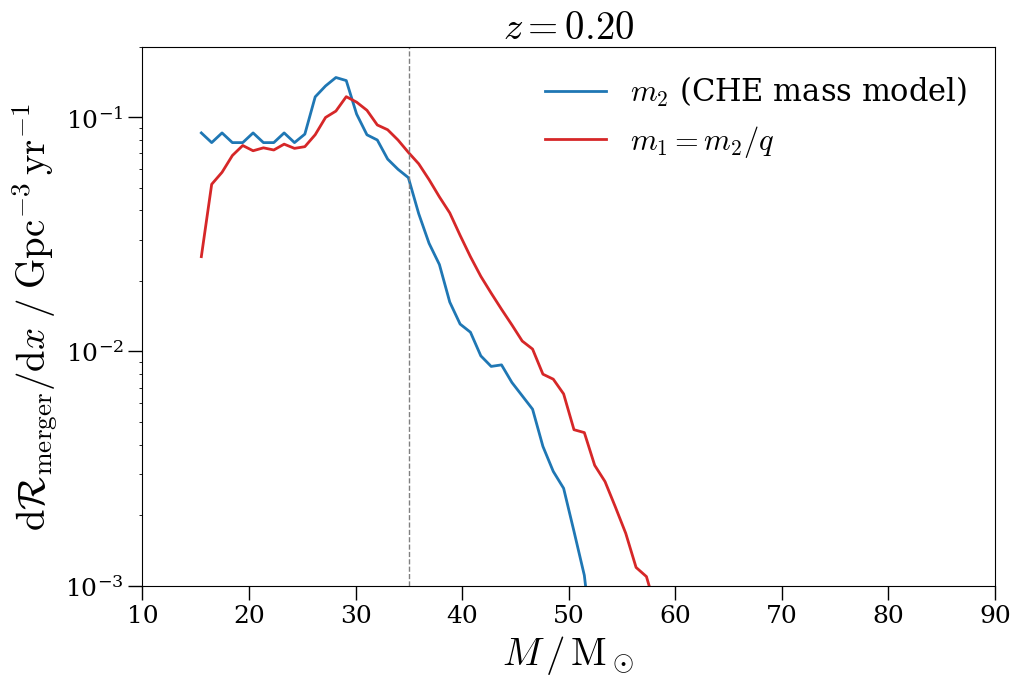

In [40]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_pairing_marginals(m1_paired, m2_paired, w_paired, redshift=z_paired, ax=ax)
ax.set_xlim(10, 90)
ax.set_ylim(1e-3, 2e-1)
savefig(fig, 'pairing_marginals_m1_m2')

In [41]:
def plot_pairing_joint(
    m1,
    m2,
    weights,
    m1_bins=None,
    m2_bins=None,
    n_bins=60,
    log_color=True,
    cmap='magma',
    show_diagonal=True,
    peak_mass=35.0,
    redshift=None,
    ax=None,
    colorbar=True,
):
    """Plot the joint (m1, m2) differential merger rate of the paired sample.

    Parameters
    ----------
    m1, m2, weights : array_like
        Paired sample from :func:`pair_che_masses`.
    m1_bins, m2_bins : numpy.ndarray, optional
        Bin edges; built from the sample range when omitted.
    n_bins : int
        Number of bins per axis when edges are omitted.
    log_color : bool
        Logarithmic colour normalisation, with empty bins masked.
    cmap : str
        Colormap for the rate.
    show_diagonal : bool
        Draw the ``m1 = m2`` line bounding the populated region.
    peak_mass : float or None
        Draw reference lines at this mass on both axes.
    redshift : float, optional
        Annotate the axes with this redshift.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.
    colorbar : bool
        Attach a colorbar.

    Returns
    -------
    ax : matplotlib.axes.Axes
    mesh : matplotlib.collections.QuadMesh
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    if m1_bins is None:
        m1_bins = np.linspace(m1.min(), m1.max(), n_bins + 1)
    if m2_bins is None:
        m2_bins = np.linspace(m2.min(), m2.max(), n_bins + 1)

    rate, x_edges, y_edges = differential_rate_2d(m1, m2, weights, m1_bins, m2_bins)

    plot_rate = np.ma.masked_where(rate <= 0, rate) if log_color else rate
    norm = LogNorm(vmin=plot_rate.min(), vmax=plot_rate.max()) if log_color else None
    mesh = ax.pcolormesh(x_edges, y_edges, plot_rate.T, cmap=cmap, norm=norm, shading='flat')

    if show_diagonal:
        edge = [max(x_edges[0], y_edges[0]), min(x_edges[-1], y_edges[-1])]
        ax.plot(edge, edge, ls='--', lw=1.5, color='w')

    # add labels and scales
    ax.set_xlabel(r'$m_1\,/\,\mathrm{M}_\odot$')
    ax.set_ylabel(r'$m_2\,/\,\mathrm{M}_\odot$')
    if peak_mass is not None:
        ax.axvline(peak_mass, ls=':', lw=1, color='w')
        ax.axhline(peak_mass, ls=':', lw=1, color='w')
    if redshift is not None:
        ax.set_title(rf'$z = {redshift:.2f}$')
    if colorbar:
        cbar = ax.figure.colorbar(mesh, ax=ax)
        cbar.set_label(
            r'$\mathrm{d}^2\mathcal{R}_\mathrm{merger}/\mathrm{d}m_1\,\mathrm{d}m_2$'
            r'$\;/\;\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}$',
            fontsize=18,
        )
    return ax, mesh

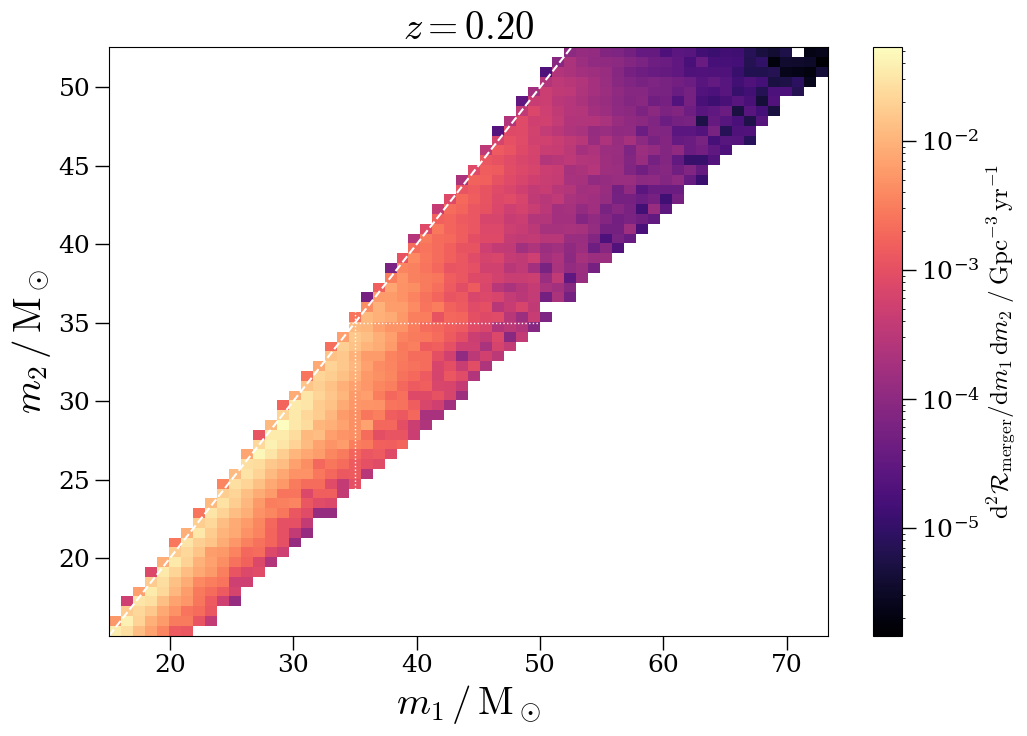

In [42]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_pairing_joint(m1_paired, m2_paired, w_paired, redshift=z_paired, ax=ax)
fig.tight_layout()
savefig(fig, 'pairing_joint_m1_m2')

m1 model support : 15.05 - 73.33 Msun
m1 model rate    : 2.0249e+00 Gpc^-3 yr^-1


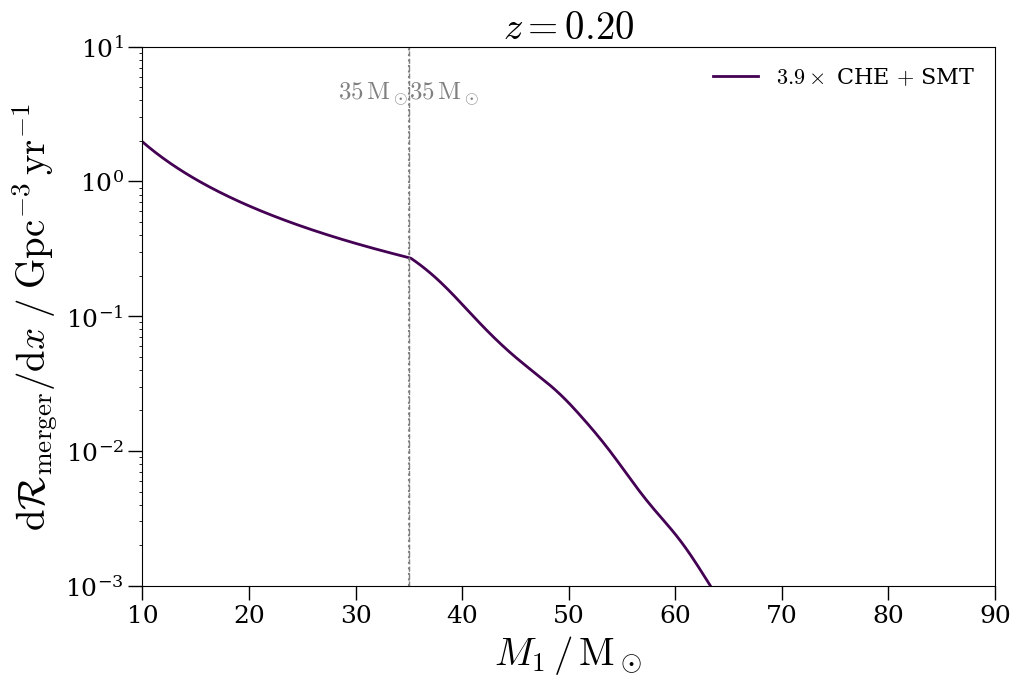

In [43]:
# the emergent m1 distribution becomes the CHE component of the mixture
m1_model = SmoothedRateModel(
    m1_paired, w_paired,
    bandwidth=MIXTURE_BANDWIDTH, space='linear',
    parameter='m_1', redshift=z_paired,
)

print(f'm1 model support : {m1_model.support[0]:.2f} - {m1_model.support[1]:.2f} Msun')
print(f'm1 model rate    : {m1_model.total_rate:.4e} Gpc^-3 yr^-1')

fig, ax = plt.subplots(figsize=(11, 7))
plot_population_mixture(
    m1_model,
    mass_grid=np.linspace(5.0, 120.0, 500),
    che_scales=3.9,
    ax=ax,
    transition=35
)
ax.set_ylim(1e-3, 1e1)
ax.set_xlim(10, 90)
savefig(fig, 'pairing_mixture_m1_lvk')

## Appendix: COMPAS vs project end-to-end comparison

The script `scripts/compare_compas_vs_project_rates.py` computes merger rates
using the original COMPAS `FastCosmicIntegration` functions and the refactored
`src.merger_rates` module, each with **its own normalisation**. The core loop
(metallicity reweighting, delay-time convolution) is identical; the normalization
differs because the two methods compute `M_per_binary` differently.

The entire difference is a **uniform scale factor**, decomposed into:
- **Issue A** — COMPAS uses a `m2_min`-based q cut (joint mass-ratio fraction),
  while the project uses an explicit flat `q_min` cut appropriate for CHE.
- **Issue B** — COMPAS has no period fraction; the project includes `f_p`.
- **Residual** — IMF parametrisation difference (2-segment [0.08, 300] vs
  3-segment [0.01, 200]).


M_per_binary (COMPAS)  : 412.85 Msun
M_per_binary (project) : 1450.02 Msun
Total rate (COMPAS)    : 5.8577e+00 Gpc^-3 yr^-1
Total rate (project)   : 1.6678e+00 Gpc^-3 yr^-1
Ratio (COMPAS/project) : 3.51x  (uniform scale factor)
  Issue A (q handling) : 2.00x
  Issue B (period)     : 1.80x
  A x B               : 3.60x
  IMF residual         : 1.0245  (+2.4%)


/tmp/ipykernel_3713399/757011374.py:50: RuntimeWarning: invalid value encountered in divide
  residual = np.where(safe, dRdm_project / dRdm_compas, np.nan)
/tmp/ipykernel_3713399/757011374.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


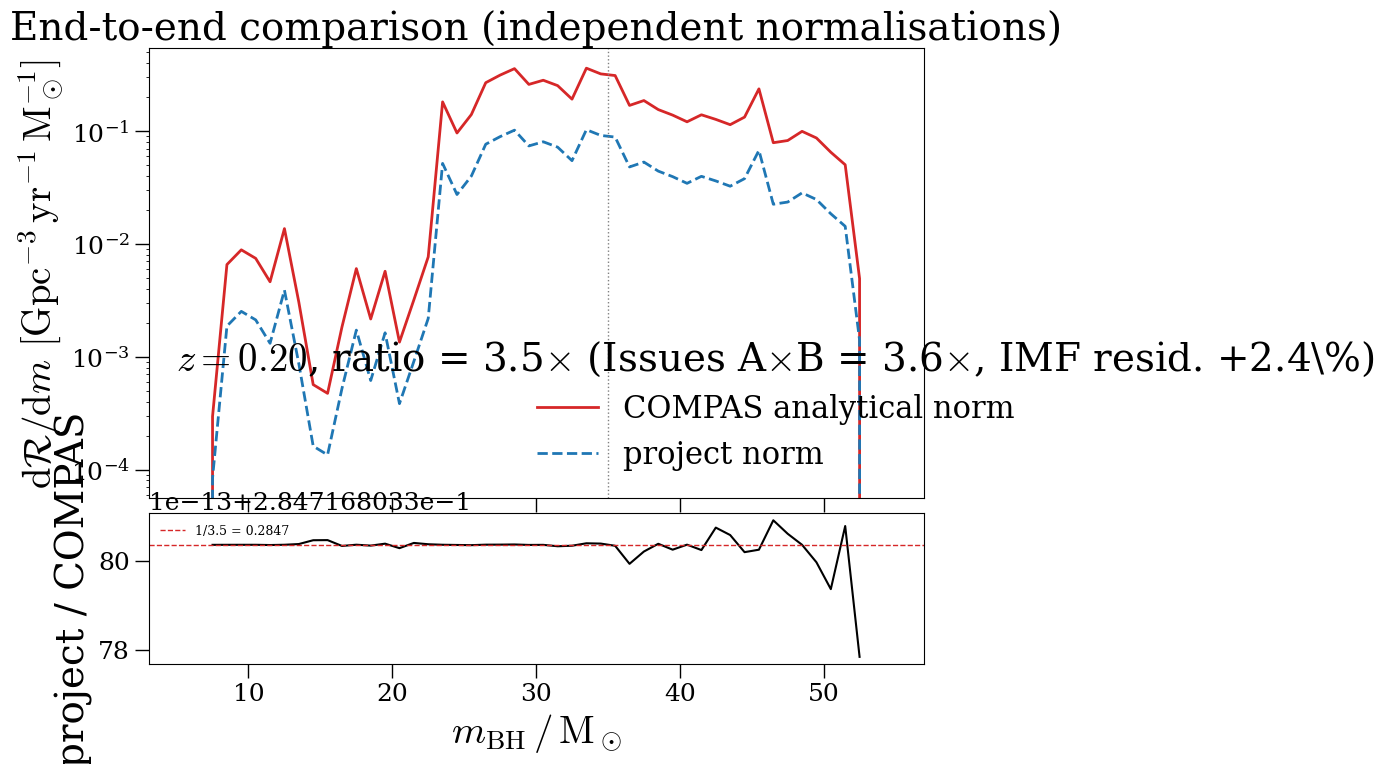

In [44]:
comp_path = Path('..') / 'scripts/output/compare_compas_vs_project_rates.npz'
comp = np.load(comp_path)

m_centers = comp['mass_centers']
dRdm_compas = comp['dRdm_compas']
dRdm_project = comp['dRdm_project']
z_comp = float(comp['z_comparison'])
total_compas = float(comp['total_rate_compas'])
total_project = float(comp['total_rate_project'])
ratio = total_compas / total_project

m_per_binary_compas = float(comp['m_per_binary_compas'])
m_per_binary_project = float(comp['m_per_binary_project'])
issue_a = float(comp['issue_a_factor'])
issue_b = float(comp['issue_b_factor'])
imf_residual = float(comp['imf_residual'])

print(f'M_per_binary (COMPAS)  : {m_per_binary_compas:.2f} Msun')
print(f'M_per_binary (project) : {m_per_binary_project:.2f} Msun')
print(f'Total rate (COMPAS)    : {total_compas:.4e} Gpc^-3 yr^-1')
print(f'Total rate (project)   : {total_project:.4e} Gpc^-3 yr^-1')
print(f'Ratio (COMPAS/project) : {ratio:.2f}x  (uniform scale factor)')
print(f'  Issue A (q handling) : {issue_a:.2f}x')
print(f'  Issue B (period)     : {issue_b:.2f}x')
print(f'  A x B               : {issue_a * issue_b:.2f}x')
print(f'  IMF residual         : {imf_residual:.4f}  ({(imf_residual-1)*100:+.1f}%)')

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), height_ratios=[3, 1],
    sharex=True, gridspec_kw={'hspace': 0.05},
)

ax1.plot(m_centers, dRdm_compas, 'C3-', lw=2, label='COMPAS analytical norm')
ax1.plot(m_centers, dRdm_project, 'C0--', lw=2, label='project norm')
ax1.axvline(35, ls=':', lw=1, color='gray')
ax1.set_ylabel(
    r'$\mathrm{d}\mathcal{R}/\mathrm{d}m$'
    r' $[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}\,\mathrm{M}_\odot^{-1}]$'
)
ax1.set_yscale('log')
ax1.legend(
    title=(rf'$z = {z_comp:.2f}$, ratio = {ratio:.1f}$\times$'
           rf' (Issues A$\times$B = {issue_a * issue_b:.1f}$\times$,'
           rf' IMF resid. {(imf_residual-1)*100:+.1f}\%)'),
    frameon=False,
)
ax1.set_title('End-to-end comparison (independent normalisations)')

safe = dRdm_compas > 0
residual = np.where(safe, dRdm_project / dRdm_compas, np.nan)
ax2.plot(m_centers, residual, 'k-', lw=1.5)
ax2.axhline(1.0 / ratio, ls='--', lw=1, color='C3',
            label=f'1/{ratio:.1f} = {1/ratio:.4f}')
ax2.set_xlabel(r'$m_\mathrm{BH}\,/\,\mathrm{M}_\odot$')
ax2.set_ylabel('project / COMPAS')
ax2.legend(frameon=False, fontsize=9)

fig.tight_layout()
savefig(fig, 'compas_vs_project_end_to_end')


## Notes

- **Normalization convention.** `compute_merger_rates` normalises by
  `mean(m_zams)` over `full_population` (the full MC sample including non-CHE
  systems) and divides by `len(full_population)`. The mean mass is the Kroupa
  mean over the sampled range [10, 300] M$_\odot$, and `get_mass_fraction`
  computes the **mass fraction** (not number fraction) of the IMF in that range
  to account for the total stellar mass budget. This is algebraically equivalent
  to using the full-IMF mean mass with a number fraction.
- **COMPAS comparison.** The 3.5$\times$ ratio between COMPAS and project rates
  is a uniform scale factor, fully explained by two CHE-specific issues in COMPAS's
  general-purpose normalisation: (A) `m2_min`-based q cut vs flat `q_min` (2.0$\times$)
  and (B) missing period fraction (1.8$\times$). The 2% residual comes from
  different IMF parametrisations (2-segment [0.08, 300] vs 3-segment [0.01, 200]).
- **Fixed redshift.** Rates are read directly off the fine redshift grid
  (`redshift_step = 0.01`), not volume-averaged over a coarse bin, so
  `weights.sum()` is exactly $\mathcal{R}(z)$.
- **PISN systems.** `m_post_pi == 0` marks systems that leave no remnant; they are
  dropped from `m_post_pi` histograms via `drop_pisn=True`, which is why the
  `m_post_pi` and `m_f` curves do not integrate to the same total rate.
- **Other populations.** Point `POP_PATH` at any `ip_pop_*_df.h5` file and re-run.
  The 9-column files lack `p_orb_f`, `x_min_f`, `m_tams` and `x_tams`; the printed
  parameter list in the loading cell shows what is available.
- **Mixture model.** Both channels carry their real normalisation and are summed,
  never renormalised on the plotted grid: CHE the rate from the cosmic integration
  scaled by `che_scale`, SMT the observed `LVK_MERGER_RATE`. They are split at
  `TRANSITION_MASS`: SMT is null at and above it, CHE null below it, so each channel
  integrates to less than its own total rate. The KDE should not be
  trusted within about one bandwidth of the CHE window edges or the PISN gap edge,
  where a fixed-width kernel smears a sharp boundary.
- **LVK component.** The mixture uses `lvk_low_mass_peak`, the untruncated
  $m^{-\alpha_1}\,S(m)$ first branch that makes the ~10 M$_\odot$ peak, not the full broken
  power law, cut off at `TRANSITION_MASS` and scaled to `LVK_MERGER_RATE`.
  `LVK_LOW_MASS_PEAK`, `LVK_BROKEN_POWER_LAW` and `LVK_MERGER_RATE` hold published values as
  a convenience; check them against the posterior you intend to quote before using the
  comparison in a paper. `LVK_MERGER_RATE` is a z ~ 0.2 number, so comparing at another
  redshift needs the LVK rate evolution rather than this constant.
